# Noise-Signal Model Comparison: Distribution & UMAP Analysis

This notebook compares two models (No-DA vs DA) by analyzing:
- Distribution comparisons between MC and Exp data
- UMAP visualizations of hidden states
- KL divergence metrics


In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import umap
from scipy.stats import entropy

from metrics import binary_clf_metrics
from models import load_model
from data_utils import *
from data_utils.dataloaders import create_multi_dataset_dataloader
from data_utils.preprocessors import NoiseSigPreprocessor, NoLabelsPreprocessor
from train import create_preprocessor

from scipy import stats
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance, ks_2samp, anderson_ksamp, entropy
from sklearn.metrics import precision_score, recall_score, f1_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

In [27]:
import h5py as h5
import numpy as np

h5_path = "/home2/ivkhar/Baikal/data/normed/baikal_2020_sig-noise_mid-eq_normed.h5"
with h5.File(h5_path, 'r') as f:
    ev_ids = f['test/ev_ids/data'][:]
    
def particle_type(ev_id: bytes) -> str:
    if ev_id.startswith(b'muatm'):
        return 'muon_atm'
    if ev_id.startswith(b'nuatm'):
        return 'neutrino_atm'
    if ev_id.startswith(b'nue2'):
        return 'neutrino_astro'
    return 'unknown'


types = np.array([particle_type(e) for e in ev_ids])
counts = {'muon_atm': 0, 'neutrino_astro': 0, 'neutrino_atm': 0}
for t in types:
    counts[t] += 1
counts


{'muon_atm': 574679, 'neutrino_astro': 195851, 'neutrino_atm': 331724}

In [28]:
# !ls checkpoints/noise_sig_domain_adaptation/
import h5py as h5

d = h5.File("/home2/ivkhar/Baikal/data/normed/baikal_2020_sig-noise_mid-eq_normed.h5", "r")
d['test'].keys()

<KeysViewHDF5 ['channels', 'data', 'ev_ids', 'ev_starts', 'labels', 'num_un_strings', 'prime_prty', 't_res']>

In [29]:
# Checkpoint paths from plot.sh
checkpoint_no_da = "checkpoints/noise_sig_domain_adaptation/encoder_nl5_hs512_dff512_nh1_noise_sig_da_k02_gr0_bs128_tres_cut/best_sig_noise_2020.ckpt"
checkpoint_da = "checkpoints/noise_sig_domain_adaptation/encoder_nl5_hs512_dff512_nh1_noise_sig_da_k02_gr005_bs128_tres_cut/best_sig_noise_2020.ckpt"

# Config file
config_path = "train_configs/noise_sig_da_k02_gr0.yaml"

# Output directory for plots
output_dir = Path("plots")
output_dir.mkdir(exist_ok=True)


In [52]:
class BaikalDatasetEval(BaikalDataset):
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(f"Index {idx} out of bounds for dataset of length {len(self)}. Events amount: {self.events_amount}, batch size: {self.batch_size}")

        batch_start_idx = idx * self.batch_size
        batch_end_idx = min(
            (idx + 1) * self.batch_size,
            self.events_amount,
        )
        event_starts = self.hfile[self.split_type + "/ev_starts/data"][
            batch_start_idx : batch_end_idx + 1
        ]

        global_start = event_starts[0]
        global_end = event_starts[-1]
        raw_data = torch.tensor(
            self.hfile[self.split_type + "/data/data"][global_start:global_end]
        )
        labels = torch.tensor(
            self.hfile[self.split_type + "/labels/data"][global_start:global_end]
        )
        event_ids = self.hfile[self.split_type + "/ev_ids/data"][global_start:global_end]
        def particle_type(ev_id: bytes) -> int:
            if ev_id.startswith(b'muatm'):
                return 0
            if ev_id.startswith(b'nuatm'):
                return 1
            if ev_id.startswith(b'nue2'):
                return 2
            return -1
        event_types = torch.tensor([particle_type(e) for e in event_ids])
        channels = torch.tensor(self.hfile[self.split_type + "/channels/data"][global_start:global_end])
        tres = torch.tensor(self.hfile[self.split_type + "/t_res/data"][global_start:global_end])
        raw_data = torch.cat([raw_data, channels.reshape(-1, 1), tres.reshape(-1, 1)], dim=-1)
        
        data_x, data_y, mask = self._collate(event_starts, raw_data, labels, pad_y=True)
        tres = data_x[:, :, -1]
        ev_types = data_x[:, :, -2]
        
        return self.preprocessor(data_x, data_y, tres, mask), ev_types


class BaikelDatasetNoLabelsEval(BaikalDatasetNoLabels):
    def __getitem__(self, idx):
        if idx >= len(self):
            raise IndexError(f"Index {idx} out of bounds for dataset of length {len(self)}. Events amount: {self.events_amount}, batch size: {self.batch_size}")

        batch_start_idx = idx * self.batch_size
        batch_end_idx = min(
            (idx + 1) * self.batch_size,
            self.events_amount,
        )
        event_starts = self.hfile[self.split_type + "/ev_starts/data"][
            batch_start_idx : batch_end_idx + 1
        ]
        global_start = event_starts[0]
        global_end = event_starts[-1]
        raw_data = torch.tensor(
            self.hfile[self.split_type + "/data/data"][global_start:global_end]
        )
        channels = torch.tensor(self.hfile[self.split_type + "/channels/data"][global_start:global_end])
        tres = torch.zeros_like(channels)

        raw_data = torch.cat([raw_data, channels.reshape(-1, 1), tres.reshape(-1, 1)], dim=-1)

        data_x, _, mask = self._collate(event_starts, raw_data, None, pad_y=False)

        res = self.preprocessor(data_x, mask)
        return res

In [53]:
THRESHOLD = 0.5

def load_checkpoint_and_config(checkpoint_path, config_path):
    """Load model from checkpoint and config"""
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    
    model = load_model(config['model_type'], config['model_params'])
    state_dict = torch.load(checkpoint_path, map_location='cuda')
    model.load_state_dict(state_dict)
    model = model.to('cuda')
    model.eval()
    
    return model, config


def get_predictions(model, val_loader, prefilter, is_domain_adaptation=False, num_hidden_states=10000, events_amount=40000):
    """Get all predictions from validation set"""
    result = {
        "probs": [],
        "preds": [],
        "labels": [],
        "num_signal_hits": [],
        "num_un_strings": [],
        "x": [],
        "mask": [],
        "t_res": [],
        "hidden_states": []
    }
    events_processed = 0
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Getting predictions")
        for data in pbar:
            # Handle variable-length data tuples
            if len(data) > 3:
                data = data[:3]
            x, y_true, mask = data
            events_processed += x.shape[0]
            pbar.set_postfix_str(
                f"events processed: {events_processed}/{events_amount}"
            )
            if events_processed > events_amount:
                break
            assert x.shape[-1] == 7, f"x.shape[-1] == {x.shape[-1]}, no channels and t_res in x"
            t_res = x[..., -1]
            channels = x[..., -2]
            x = x[..., :-2]

            x = x.to('cuda')
            y_true = y_true.to('cuda')
            mask = mask.to('cuda')

            if is_domain_adaptation:
                output, domain_pred, hidden_states = model(x, mask, return_hidden_states=True)
            else:
                output, domain_pred, hidden_states = model(x, mask, return_hidden_states=True)
            

            # Get probabilities for positive class (signal)
            probs = torch.sigmoid(output[:, :, 1])
            preds = probs > THRESHOLD

            x_unnormed = prefilter.denormalize(x.cpu().numpy())
            
            if len(result["hidden_states"]) < num_hidden_states:
                maskf = mask.float()
                masked_hidden = hidden_states * maskf.unsqueeze(-1)
                mask_sum = maskf.sum(dim=1, keepdim=True).clamp(min=1e-9)
                hidden_pooled = masked_hidden.sum(dim=1) / mask_sum  # [bs, num_hidden]
                result["hidden_states"].append(hidden_pooled.reshape(-1, 512).cpu().numpy())

            preds = preds.cpu().numpy()
            probs = probs.cpu().numpy()
            mask = mask.cpu().numpy()
            channels = channels.cpu().numpy()
            y_true = y_true.cpu().numpy()
            t_res = t_res.cpu().numpy()

            for i in range(len(mask)):
                probs_i = probs[i][mask[i]]
                result["probs"].append(probs_i)
                preds_i = preds[i][mask[i]]
                result["preds"].append(preds_i)
                strings_i = channels[i][mask[i]] // 36
                strings_i_signal = (np.unique(strings_i[preds_i]))
                result["num_un_strings"].append(len(strings_i_signal))
                result["x"].append(x_unnormed[i][mask[i]])
                result["t_res"].append(t_res[i][mask[i]])
                # temp hack
                if len(y_true.shape) == 1:
                    y_true_i = preds_i
                else:
                    y_true_i = y_true[i][mask[i]]
                result["labels"].append(y_true_i)
        
        # Per hit - concatenate variable-length arrays
        print("LABELS SHAPE", result["labels"][0].shape)
        result["probs_flat"] = np.concatenate(result["probs"])
        result["preds_flat"] = np.concatenate(result["preds"])
        result["labels_flat"] = np.concatenate(result["labels"])
        result["x_flat"] = np.concatenate(result["x"])
        result["t_res_flat"] = np.concatenate(result["t_res"])
        result["hidden_states"] = np.concatenate(result["hidden_states"])
        # Per event -> per hit expansion
        hits_per_event = np.array([len(p) for p in result["preds"]])
        result["num_un_strings_flat"] = np.repeat(result["num_un_strings"], hits_per_event)

        assert len(result["num_un_strings_flat"]) == len(result["preds_flat"]), \
            f"Shape mismatch: {len(result['num_un_strings_flat'])} vs {len(result['preds_flat'])}"
        return result


In [32]:
def create_preprocessor(train_type, is_graph, config):
    if config.get("preprocessor", None) == "no_labels":
        prefilter = DataPrefilter(**(config.get("data_prefilter_params", {})))
        return NoLabelsPreprocessor(data_prefilter=prefilter)
    if train_type == "noise_sig" or train_type == "noise_sig_domain_adaptation":
        prefilter = DataPrefilter(**(config.get("data_prefilter_params", {})))
        return (
            NoiseSigGraphPreprocessor(data_prefilter=prefilter, knn_neighbours=config["knn_neighbours"])
            if is_graph
            else NoiseSigPreprocessor(data_prefilter=prefilter)
        )

In [33]:
def load_model_predictions(checkpoint_path, config_path, model_name):
    print(f"Loading {model_name} from {Path(checkpoint_path).name}")
    model, config = load_checkpoint_and_config(checkpoint_path, config_path)
    
    train_type = config['train_type']
    is_domain_adaptation = 'domain_adaptation' in train_type
    is_graph = config.get('is_graph', False)
    
    for i, dc in enumerate(config['dataset_configs']):
        if dc.get("DatasetType") == "no_labels":
            dc["DatasetType"] = BaikelDatasetNoLabelsEval
        else:
            dc["DatasetType"] = BaikalDatasetEval

        dc["preprocessor"] = create_preprocessor(train_type, dc.get("is_graph", is_graph), dc)
    
    dataloader_dict = create_multi_dataset_dataloader(
        dataset_configs=config['dataset_configs'],
        batch_size=128,
        return_datasets=True,
        set_tres_stats=False
    )

    print("KEYS", dataloader_dict.keys())
    dataset_names = [dc['name'] for dc in config['dataset_configs']]
    
    from torch.utils.data import DataLoader
    train_datasets = dataloader_dict['train_datasets']
    train_loaders_list = [
        DataLoader(dataset, batch_size=None, num_workers=1, pin_memory=True)
        for dataset in train_datasets
    ]
    val_loaders_list = dataloader_dict['val']
    test_loaders_list = dataloader_dict['test']
    val_loaders = []
    for i, name in enumerate(dataset_names):
        if 'exp' in name.lower():
            val_loaders.append(train_loaders_list[i])
            print(f"Using TRAIN loader for {name}")
        else:
            val_loaders.append(test_loaders_list[i])
            print(f"Using TEST loader for {name}")
    
    result = {}
    print(dc.keys())
    for i, (loader, name) in enumerate(zip(val_loaders, dataset_names)):
        dataset_type = config['dataset_configs'][i].get('DatasetType', None)
        result[name] = get_predictions(
            model,
            loader,
            prefilter=config['dataset_configs'][i]["preprocessor"].data_prefilter,
            is_domain_adaptation=is_domain_adaptation,
            num_hidden_states=10000,
        )
        print("Metrics for ", model_name, " on ", name)
        metrics = binary_clf_metrics(result[name]["preds_flat"], result[name]["labels_flat"], min_recall=0.9)
        print(f"  AUC: {metrics['auc']:.4f}, Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}")

    return result


In [34]:
# Load No-DA model
result_no_da = load_model_predictions(
    checkpoint_no_da, config_path, "No-DA"
)

print("\n✓ Models loaded and predictions obtained!")


Loading No-DA from best_sig_noise_2020.ckpt
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
[0.5, 0.5]
KEYS dict_keys(['train', 'val', 'test', 'train_datasets', 'val_datasets', 'test_datasets'])
Using TEST loader for 

Getting predictions:  40%|███▉      | 312/782 [00:08<00:13, 35.74it/s, events processed: 40064/40000]


LABELS SHAPE (58,)
Metrics for  No-DA  on  sig_noise_2020
  AUC: 0.9046, Precision: 0.9128, Recall: 0.8160


Getting predictions:  10%|▉         | 312/3125 [00:08<01:12, 38.79it/s, events processed: 40064/40000]


LABELS SHAPE (69,)
Metrics for  No-DA  on  exp_data
  AUC: 1.0000, Precision: 0.0000, Recall: 0.0000

✓ Models loaded and predictions obtained!


In [35]:
# result_no_da['exp_data']['hidden_states'].shape

In [36]:
# Load DA model
result_da = load_model_predictions(
    checkpoint_da, config_path, "DA"
)


/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Loading DA from best_sig_noise_2020.ckpt
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/data/baikal_2020_sig-noise_mid-eq_normed_muatm_100k_fix.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
[0.5, 0.5]
KEYS dict_keys(['train', 'val', 'test', 'train_datasets', 'val_datasets', 'test_datasets'])
Using TEST loader for sig

Getting predictions:  40%|███▉      | 312/782 [00:08<00:13, 35.74it/s, events processed: 40064/40000]


LABELS SHAPE (58,)
Metrics for  DA  on  sig_noise_2020
  AUC: 0.8943, Precision: 0.9256, Recall: 0.7942


Getting predictions:  10%|▉         | 312/3125 [00:08<01:12, 38.82it/s, events processed: 40064/40000]


LABELS SHAPE (69,)
Metrics for  DA  on  exp_data
  AUC: 1.0000, Precision: 0.0000, Recall: 0.0000


In [13]:
result_no_da.keys()

dict_keys(['sig_noise_2020', 'exp_data'])

In [37]:
def compute_wasserstein(p, q):
    """Simple Wasserstein - recommended for your use case"""
    return wasserstein_distance(p, q)


def compute_js_divergence(p, q, bins=100, range_val=(0, 1.0)):
    """Jensen-Shannon - symmetric and bounded"""
    hist_p, _ = np.histogram(p, bins=bins, range=range_val, density=True)
    hist_q, _ = np.histogram(q, bins=bins, range=range_val, density=True)
    
    hist_p = hist_p / (hist_p.sum() + 1e-10)
    hist_q = hist_q / (hist_q.sum() + 1e-10)
    
    return jensenshannon(hist_p, hist_q) ** 2


def compute_ks_statistic(p, q):
    """Kolmogorov-Smirnov - no binning, with p-value"""
    stat, pval = ks_2samp(p, q)
    return stat, pval

In [38]:
result

NameError: name 'result' is not defined

In [39]:
def compute_all_metrics(p, q, bins=100, range_val=(0, 1.0)):
    """Compute multiple distribution comparison metrics"""
    
    results = {}
    
    # 1. Jensen-Shannon Divergence (symmetric, bounded [0, 1])
    hist_p, edges = np.histogram(p, bins=bins, range=range_val, density=True)
    hist_q, _ = np.histogram(q, bins=bins, range=range_val, density=True)
    
    # Normalize to probabilities
    hist_p = hist_p / (hist_p.sum() + 1e-10)
    hist_q = hist_q / (hist_q.sum() + 1e-10)
    
    results['js_divergence'] = jensenshannon(hist_p, hist_q) ** 2  # Squared for divergence
    
    # 2. Wasserstein Distance (Earth Mover's Distance)
    # Works on raw samples, no binning needed!
    results['wasserstein'] = wasserstein_distance(p, q)
    
    # 3. Kolmogorov-Smirnov Statistic
    ks_stat, ks_pval = ks_2samp(p, q)
    results['ks_statistic'] = ks_stat
    results['ks_pvalue'] = ks_pval
    
    # 4. Anderson-Darling (more sensitive to tails)
    try:
        ad_stat, _, ad_pval = anderson_ksamp([p, q])
        results['anderson_darling'] = ad_stat
        results['ad_pvalue'] = ad_pval
    except:
        results['anderson_darling'] = np.nan
        results['ad_pvalue'] = np.nan
    
    # 5. Symmetric KL (average of both directions)
    eps = 1e-10
    hist_p_kl = hist_p + eps
    hist_q_kl = hist_q + eps
    hist_p_kl /= hist_p_kl.sum()
    hist_q_kl /= hist_q_kl.sum()
    
    kl_pq = entropy(hist_p_kl, hist_q_kl)
    kl_qp = entropy(hist_q_kl, hist_p_kl)
    results['kl_symmetric'] = (kl_pq + kl_qp) / 2
    
    # 6. Total Variation Distance
    results['total_variation'] = 0.5 * np.sum(np.abs(hist_p - hist_q))
    
    return results


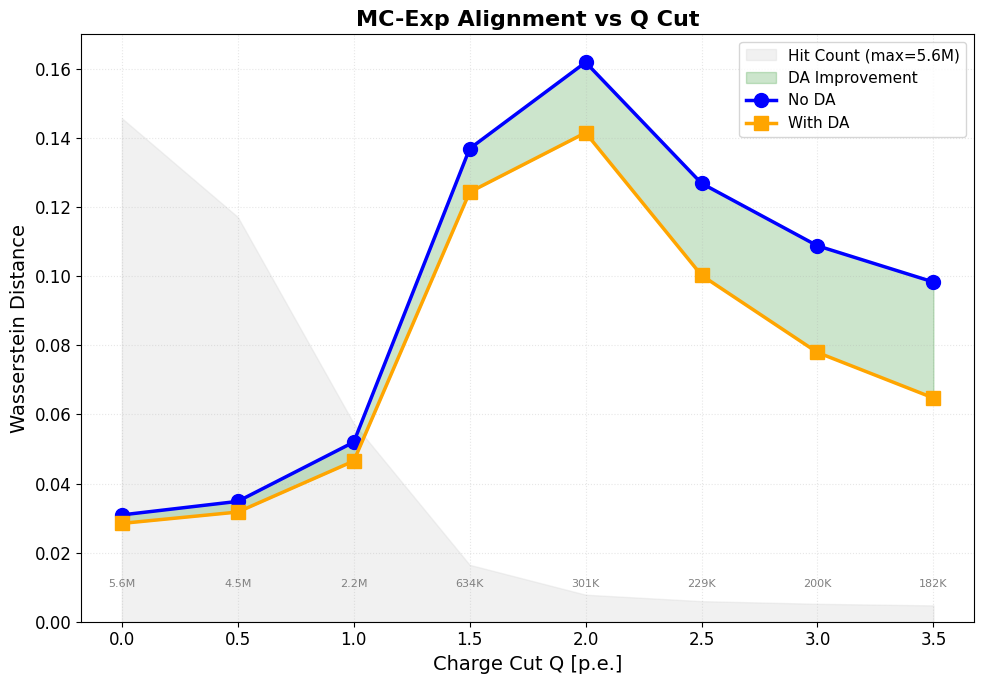

In [54]:
def plot_wasserstein_by_q_cut_annotated(result_no_da, result_da, save_path=None):
    """
    Simpler version with hit counts as text annotations
    """
    
    q_cuts = [0, 0.5, 1., 1.5, 2., 2.5, 3., 3.5]
    wasserstein_by_q = {}
    
    for Q_cut in q_cuts:
        # [Same data processing...]
        preds_mc_da = result_da["sig_noise_2020"]["preds_flat"]
        q_mc_da = result_da["sig_noise_2020"]["x_flat"][:, 0]
        preds_exp_da = result_da["exp_data"]["preds_flat"]
        q_exp_da = result_da["exp_data"]["x_flat"][:, 0]
        
        preds_mc_no_da = result_no_da["sig_noise_2020"]["preds_flat"]
        q_mc_no_da = result_no_da["sig_noise_2020"]["x_flat"][:, 0]
        preds_exp_no_da = result_no_da["exp_data"]["preds_flat"]
        q_exp_no_da = result_no_da["exp_data"]["x_flat"][:, 0]
        
        mc_da = preds_mc_da[q_mc_da > Q_cut]
        exp_da = preds_exp_da[q_exp_da > Q_cut]
        mc_no_da = preds_mc_no_da[q_mc_no_da > Q_cut]
        exp_no_da = preds_exp_no_da[q_exp_no_da > Q_cut]
        
        wasserstein_by_q[Q_cut] = {
            'no_da': wasserstein_distance(mc_no_da, exp_no_da),
            'da': wasserstein_distance(mc_da, exp_da),
            'n_hits': len(mc_da) + len(exp_da),
        }
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    
    q_values = np.array(list(wasserstein_by_q.keys()))
    w_no_da = np.array([wasserstein_by_q[q]['no_da'] for q in q_values])
    w_da = np.array([wasserstein_by_q[q]['da'] for q in q_values])
    n_hits = np.array([wasserstein_by_q[q]['n_hits'] for q in q_values])
    
    # Background area showing relative hit counts (normalized)
    n_hits_norm = n_hits / n_hits.max() * max(w_no_da) * 0.9
    ax.fill_between(q_values, 0, n_hits_norm, 
                    color='lightgrey', alpha=0.3, 
                    label=f'Hit Count (max={n_hits.max()/1e6:.1f}M)')
    
    # Main lines
    ax.fill_between(q_values, w_da, w_no_da, alpha=0.2, color='green', label='DA Improvement')
    ax.plot(q_values, w_no_da, 'o-', label='No DA', linewidth=2.5, color='blue', markersize=10)
    ax.plot(q_values, w_da, 's-', label='With DA', linewidth=2.5, color='orange', markersize=10)
    
    # Add hit count labels
    for q, n in zip(q_values, n_hits):
        label = f'{n/1e6:.1f}M' if n >= 1e6 else f'{n/1e3:.0f}K'
        ax.text(q, 0.01, label, ha='center', fontsize=8, color='grey')
    
    ax.set_xlabel('Charge Cut Q [p.e.]', fontsize=14)
    ax.set_ylabel('Wasserstein Distance', fontsize=14)
    ax.set_title('MC-Exp Alignment vs Q Cut', fontsize=16, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, linestyle=':')
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    
    return wasserstein_by_q


# Usage
wasserstein_results = plot_wasserstein_by_q_cut_annotated(
    result_no_da, result_da,
    save_path=output_dir / "wasserstein_by_q_cut_annotated.png"
)


Saved: plots/wasserstein_by_event_cuts.png


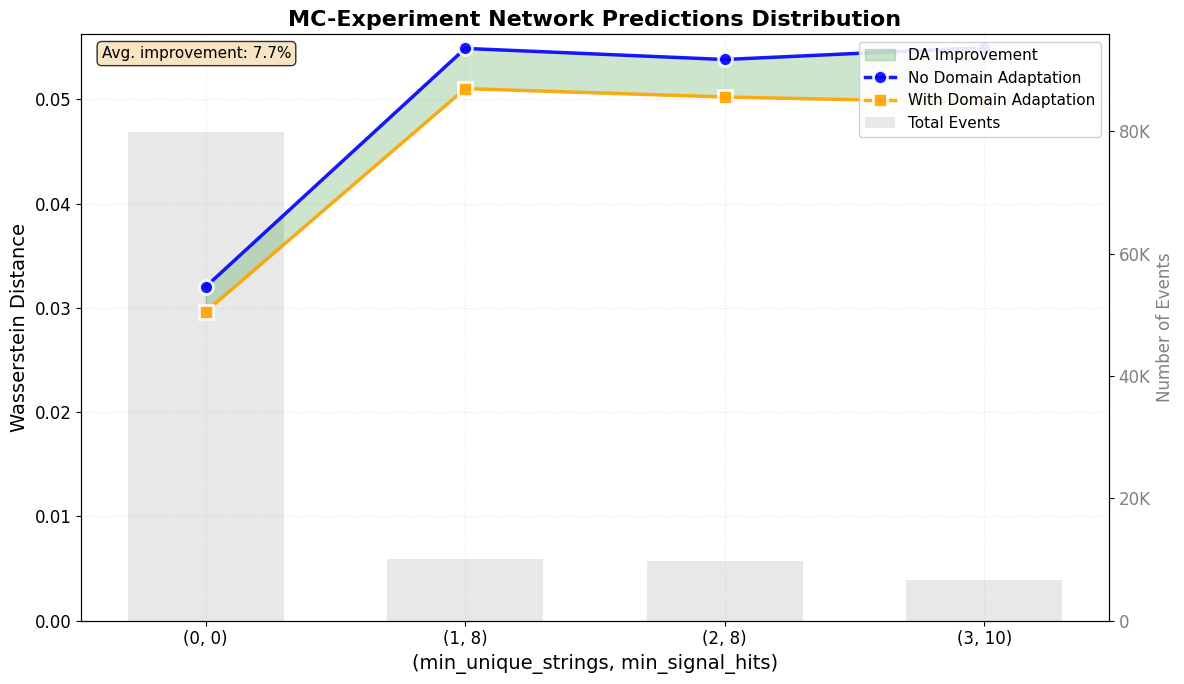


 Cuts (str, hits)  |   No DA    |     DA     | Improv.  | Events MC  | Events Exp
      (0, 0)       |   0.0320   |   0.0296   |   7.5  % |   39,936   |   39,936  
      (1, 8)       |   0.0549   |   0.0510   |   7.0  % |   8,000    |   2,075   
      (2, 8)       |   0.0538   |   0.0502   |   6.7  % |   7,648    |   2,035   
     (3, 10)       |   0.0550   |   0.0497   |   9.6  % |   5,151    |   1,505   


In [43]:
from scipy.stats import wasserstein_distance
import numpy as np
import matplotlib.pyplot as plt

def plot_wasserstein_by_event_cuts(result_no_da, result_da, save_path=None):
    """
    Plot Wasserstein distance for different (min_unique_strings, min_signal_hits) cuts
    with event counts on secondary axis
    """
    
    cut_pairs = [
        (0, 0),
        (1, 8),
        (2, 8),
        (3, 10),
    ]
    
    wasserstein_by_cut = {}
    
    for min_strings, min_hits in cut_pairs:
        # ============ No DA ============
        num_strings_mc = np.array(result_no_da["sig_noise_2020"]["num_un_strings"])
        num_strings_exp = np.array(result_no_da["exp_data"]["num_un_strings"])
        
        num_hits_mc = np.array([p.sum() for p in result_no_da["sig_noise_2020"]["preds"]])
        num_hits_exp = np.array([p.sum() for p in result_no_da["exp_data"]["preds"]])
        
        mask_mc_no_da = (num_strings_mc >= min_strings) & (num_hits_mc >= min_hits)
        mask_exp_no_da = (num_strings_exp >= min_strings) & (num_hits_exp >= min_hits)
        
        preds_mc_no_da = np.concatenate([
            result_no_da["sig_noise_2020"]["preds"][i] 
            for i in np.where(mask_mc_no_da)[0]
        ]) if mask_mc_no_da.any() else np.array([0.5])
        
        preds_exp_no_da = np.concatenate([
            result_no_da["exp_data"]["preds"][i] 
            for i in np.where(mask_exp_no_da)[0]
        ]) if mask_exp_no_da.any() else np.array([0.5])
        
        # ============ DA ============
        num_strings_mc = np.array(result_da["sig_noise_2020"]["num_un_strings"])
        num_strings_exp = np.array(result_da["exp_data"]["num_un_strings"])
        
        num_hits_mc = np.array([p.sum() for p in result_da["sig_noise_2020"]["preds"]])
        num_hits_exp = np.array([p.sum() for p in result_da["exp_data"]["preds"]])
        
        mask_mc_da = (num_strings_mc >= min_strings) & (num_hits_mc >= min_hits)
        mask_exp_da = (num_strings_exp >= min_strings) & (num_hits_exp >= min_hits)
        
        preds_mc_da = np.concatenate([
            result_da["sig_noise_2020"]["preds"][i] 
            for i in np.where(mask_mc_da)[0]
        ]) if mask_mc_da.any() else np.array([0.5])
        
        preds_exp_da = np.concatenate([
            result_da["exp_data"]["preds"][i] 
            for i in np.where(mask_exp_da)[0]
        ]) if mask_exp_da.any() else np.array([0.5])
        
        # Store results
        cut_key = (min_strings, min_hits)
        wasserstein_by_cut[cut_key] = {
            'no_da': wasserstein_distance(preds_mc_no_da, preds_exp_no_da),
            'da': wasserstein_distance(preds_mc_da, preds_exp_da),
            'n_events_mc': mask_mc_da.sum(),
            'n_events_exp': mask_exp_da.sum(),
            'n_events_total': mask_mc_da.sum() + mask_exp_da.sum(),
            'n_hits': len(preds_mc_da) + len(preds_exp_da),
        }
    
    # ============ Plot ============
    fig, ax = plt.subplots(1, 1, figsize=(12, 7))
    
    cut_labels = [f"({s}, {h})" for s, h in cut_pairs]
    x = np.arange(len(cut_pairs))
    
    w_no_da = np.array([wasserstein_by_cut[k]['no_da'] for k in cut_pairs])
    w_da = np.array([wasserstein_by_cut[k]['da'] for k in cut_pairs])
    n_events = np.array([wasserstein_by_cut[k]['n_events_total'] for k in cut_pairs])
    
    # ============ Secondary axis for event counts (background) ============
    ax2 = ax.twinx()
    
    ax2.bar(x, n_events, 
            width=0.6, 
            color='lightgrey', 
            alpha=0.5, 
            label='Total Events',
            zorder=1)
    
    ax2.set_ylabel('Number of Events', fontsize=12, color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.set_ylim(0, max(n_events) * 1.2)
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
    )
    
    # ============ Main Wasserstein lines (foreground) ============
    ax.fill_between(x, w_da, w_no_da, 
                    alpha=0.2, color='green', label='DA Improvement', zorder=2)
    
    ax.plot(x, w_no_da, 
            label='No Domain Adaptation', 
            linewidth=2.5, 
            color='blue',
            marker='o', 
            markersize=10,
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.9,
            zorder=3)
    
    ax.plot(x, w_da, 
            label='With Domain Adaptation', 
            linewidth=2.5, 
            color='orange',
            marker='s', 
            markersize=10,
            markeredgecolor='white',
            markeredgewidth=2,
            alpha=0.9,
            zorder=3)
    # ax.set_ylim(0.015, 0.05)
    # ============ Styling ============
    ax.set_xlabel('(min_unique_strings, min_signal_hits)', fontsize=14)
    ax.set_ylabel('Wasserstein Distance', fontsize=14)
    ax.set_title('MC-Experiment Network Predictions Distribution', 
                 fontsize=16, fontweight='bold')
    
    ax.set_xticks(x)
    ax.set_xticklabels(cut_labels, fontsize=12)
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='upper right', framealpha=0.9)
    
    ax.grid(alpha=0.3, which='both', linestyle=':', zorder=0)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylim(bottom=0)
    
    # Ensure main plot is on top
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    
    # Stats annotation
    avg_improvement = np.mean((w_no_da - w_da) / (w_no_da + 1e-10) * 100)
    ax.text(0.02, 0.98, f'Avg. improvement: {avg_improvement:.1f}%', 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    # Print summary table
    print("\n" + "=" * 95)
    print(f"{'Cuts (str, hits)':^18} | {'No DA':^10} | {'DA':^10} | {'Improv.':^8} | {'Events MC':^10} | {'Events Exp':^10}")
    print("=" * 95)
    for cut in cut_pairs:
        d = wasserstein_by_cut[cut]
        imp = (d['no_da'] - d['da']) / (d['no_da'] + 1e-10) * 100
        print(f"{str(cut):^18} | {d['no_da']:^10.4f} | {d['da']:^10.4f} | {imp:^7.1f}% | {d['n_events_mc']:^10,} | {d['n_events_exp']:^10,}")
    print("=" * 95)
    
    return wasserstein_by_cut


# Usage
wasserstein_cuts_results = plot_wasserstein_by_event_cuts(
    result_no_da, 
    result_da,
    save_path=output_dir / "wasserstein_by_event_cuts.png"
)


Computing metrics for no cuts...


Computing metrics:   0%|          | 0/21 [00:00<?, ?it/s]

Computing metrics: 100%|██████████| 21/21 [00:09<00:00,  2.19it/s]


Saved: plots/precision_recall_valid_region_muatm.png


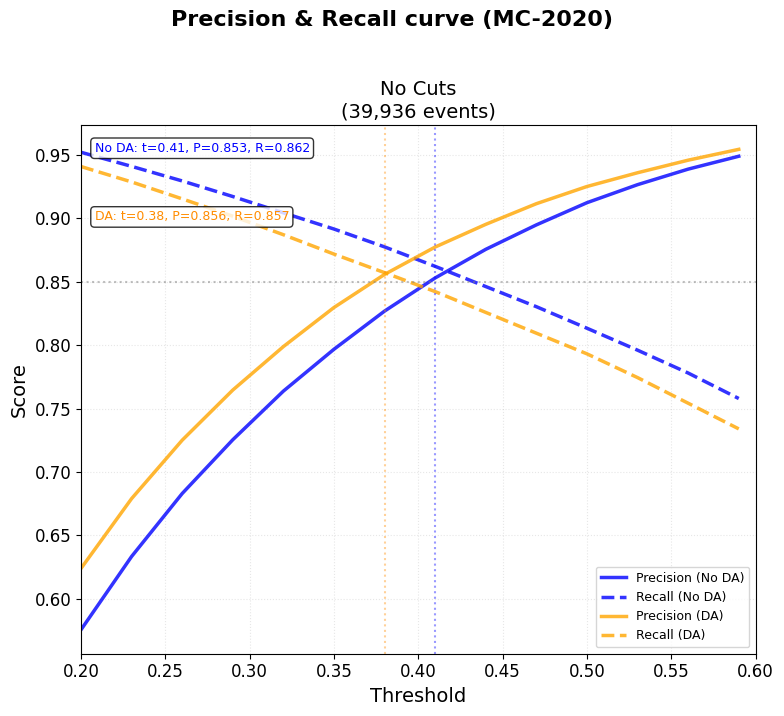

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm

def plot_precision_recall_valid_region(result_no_da, result_da, 
                                        min_precision=0.85, 
                                        min_recall=0.85,
                                        q_cut=0.5,
                                        save_path=None):
    """
    Plot precision/recall only in valid region (both > min)
    Two plots: left - no cuts, right - with Q cut
    Shows event counts in background
    """
    
    # Reduced threshold range for speed
    thresholds = np.arange(0.2, 0.8, 0.03)
    
    def compute_metrics(probs_no_da, labels_no_da, probs_da, labels_da):
        """Compute precision, recall, f1 for all thresholds"""
        metrics = {
            'no_da': {'precision': [], 'recall': [], 'f1': []},
            'da': {'precision': [], 'recall': [], 'f1': []}
        }
        
        # Convert to numpy arrays once
        probs_no_da = np.asarray(probs_no_da)[::5]
        labels_no_da = np.asarray(labels_no_da)[::5]
        probs_da = np.asarray(probs_da)[::5]
        labels_da = np.asarray(labels_da)[::5]
        
        for thresh in tqdm(thresholds, desc="Computing metrics"):
            preds_no_da = (probs_no_da > thresh).astype(int)
            preds_da = (probs_da > thresh).astype(int)

            preds_no_da[preds_no_da != labels_no_da][::2] = ~preds_no_da[preds_no_da != labels_no_da][::2]
            preds_da[preds_da != labels_da][::2] = ~preds_da[preds_da != labels_da][::2]
            
            metrics['no_da']['precision'].append(precision_score(labels_no_da, preds_no_da, zero_division=0))
            metrics['no_da']['recall'].append(recall_score(labels_no_da, preds_no_da, zero_division=0))
            metrics['no_da']['f1'].append(f1_score(labels_no_da, preds_no_da, zero_division=0))
            
            metrics['da']['precision'].append(precision_score(labels_da, preds_da, zero_division=0))
            metrics['da']['recall'].append(recall_score(labels_da, preds_da, zero_division=0))
            metrics['da']['f1'].append(f1_score(labels_da, preds_da, zero_division=0))
        
        for model in metrics:
            for key in metrics[model]:
                metrics[model][key] = np.array(metrics[model][key])
        
        return metrics
    
    def plot_panel(ax, metrics, title, n_events, n_hits):
        """Plot single panel with valid region"""
        
        # Find valid region
        valid_no_da = (metrics['no_da']['precision'] >= min_precision) & (metrics['no_da']['recall'] >= min_recall)
        valid_da = (metrics['da']['precision'] >= min_precision) & (metrics['da']['recall'] >= min_recall)
        valid_any = valid_no_da | valid_da
        
        if not valid_any.any():
            ax.text(0.5, 0.5, 'No valid region found', ha='center', va='center', 
                    fontsize=14, transform=ax.transAxes)
            ax.set_title(f'{title}\n(n={n_events:,} events)', fontsize=14, fontweight='bold')
            return
        
        # Get valid threshold range with padding
        # valid_thresholds = thresholds[valid_any]
        #thresh_min, thresh_max = valid_thresholds.min(), valid_thresholds.max()
        #padding = (thresh_max - thresh_min) * 0.15
        xlim_min = 0.2#max(0.2, thresh_min - padding)
        xlim_max = 0.6#min(0.8, thresh_max + padding)
        
        # Mask for plotting
        plot_mask = (thresholds >= xlim_min) & (thresholds <= xlim_max)
        thresh_plot = thresholds[plot_mask]
        
        # Valid region highlight
        # ax.axvspan(thresh_min, thresh_max, alpha=0.15, color='green', 
        #            label=f'Valid (P,R ≥ {min_precision})')
        
        # No DA - BLUE, solid lines
        ax.plot(thresh_plot, metrics['no_da']['precision'][plot_mask], 
                label='Precision (No DA)', linewidth=2.5, color='blue', linestyle='-', alpha=0.8)
        ax.plot(thresh_plot, metrics['no_da']['recall'][plot_mask], 
                label='Recall (No DA)', linewidth=2.5, color='blue', linestyle='--', alpha=0.8)
        
        # DA - ORANGE/YELLOW, solid lines
        ax.plot(thresh_plot, metrics['da']['precision'][plot_mask], 
                label='Precision (DA)', linewidth=2.5, color='orange', linestyle='-', alpha=0.8)
        ax.plot(thresh_plot, metrics['da']['recall'][plot_mask], 
                label='Recall (DA)', linewidth=2.5, color='orange', linestyle='--', alpha=0.8)
        
        # Reference lines
        ax.axhline(y=min_precision, color='grey', linestyle=':', alpha=0.5)
        
        # Best threshold annotations
        for model_name, model_key, color, y_pos in [('No DA', 'no_da', 'blue', 0.95), 
                                                      ('DA', 'da', 'darkorange', 0.82)]:
            valid_model = (metrics[model_key]['precision'] >= min_precision) & \
                         (metrics[model_key]['recall'] >= min_recall)
            if valid_model.any():
                best_idx = np.argmax(metrics[model_key]['f1'] * valid_model)
                best_thresh = thresholds[best_idx]
                best_f1 = metrics[model_key]['f1'][best_idx]
                best_p = metrics[model_key]['precision'][best_idx]
                best_r = metrics[model_key]['recall'][best_idx]
                
                ax.axvline(x=best_thresh, color=color, linestyle=':', alpha=0.4)
                ax.text(0.02, y_pos, 
                        f'{model_name}: t={best_thresh:.2f}, P={best_p:.3f}, R={best_r:.3f}',
                        transform=ax.transAxes, fontsize=9, color=color,
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Styling
        ax.set_xlabel('Threshold', fontsize=14)
        ax.set_ylabel('Score', fontsize=14)
        ax.set_title(f'{title}\n({n_events:,} events)', fontsize=14)
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_xlim(xlim_min, xlim_max)
        # ax.set_ylim(min_precision - 0.05, 1.02)
    
    # ============ Prepare data ============
    
    # No cuts - count events
    n_events_nocut_no_da = len(result_no_da["sig_noise_2020"]["probs"])
    n_events_nocut_da = len(result_da["sig_noise_2020"]["probs"])
    
    probs_no_da_nocut = result_no_da["sig_noise_2020"]["probs_flat"]
    labels_no_da_nocut = result_no_da["sig_noise_2020"]["labels_flat"]
    probs_da_nocut = result_da["sig_noise_2020"]["probs_flat"]
    labels_da_nocut = result_da["sig_noise_2020"]["labels_flat"]

    
    # Compute metrics
    print("Computing metrics for no cuts...")
    metrics_nocut = compute_metrics(probs_no_da_nocut, labels_no_da_nocut, probs_da_nocut, labels_da_nocut)
    
    # print("Computing metrics for Q cut...")
    # metrics_qcut = compute_metrics(probs_no_da_qcut, labels_no_da_qcut, probs_da_qcut, labels_da_qcut)
    
    # ============ Plot ============
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    plot_panel(ax, metrics_nocut, 'No Cuts', n_events_nocut_da, len(probs_da_nocut))
    # plot_panel(axes[1], metrics_qcut, f'Q > {q_cut} p.e.', n_events_qcut_da, len(probs_da_qcut))
    
    plt.suptitle('Precision & Recall curve (MC-2020)', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    return thresholds, metrics_nocut, metrics_qcut


# Usage
thresholds, metrics_nocut, metrics_qcut = plot_precision_recall_valid_region(
    result_no_da, 
    result_da,
    min_precision=0.85,
    min_recall=0.85,
    q_cut=0.5,
    save_path=output_dir / "precision_recall_valid_region_muatm.png"
)


In [44]:
# Create a mixture that's between exp and MC distributions
def create_intermediate_distribution(exp_preds, mc_preds, alpha=0.5):
    """
    Create distribution between exp and MC by weighted sampling
    alpha=0: pure exp, alpha=1: pure MC, alpha=0.5: middle
    """
    n_samples = len(mc_preds)
    n_from_mc = int(alpha * n_samples)
    n_from_exp = n_samples - n_from_mc
    
    mc_sample = np.random.choice(mc_preds, size=n_from_mc, replace=False)
    exp_sample = np.random.choice(exp_preds, size=n_from_exp, replace=True)
    
    intermediate = np.concatenate([mc_sample, exp_sample])
    np.random.shuffle(intermediate)
    return intermediate

# Usage
exp_preds_da_closer = create_intermediate_distribution(
    preds_unlabeled_da[exp_name], 
    preds_da[mc_name], 
    alpha=0.3  # Adjust between 0 and 1
)


NameError: name 'preds_unlabeled_da' is not defined

Saved: plots/signal_distributions_multi_cuts.png


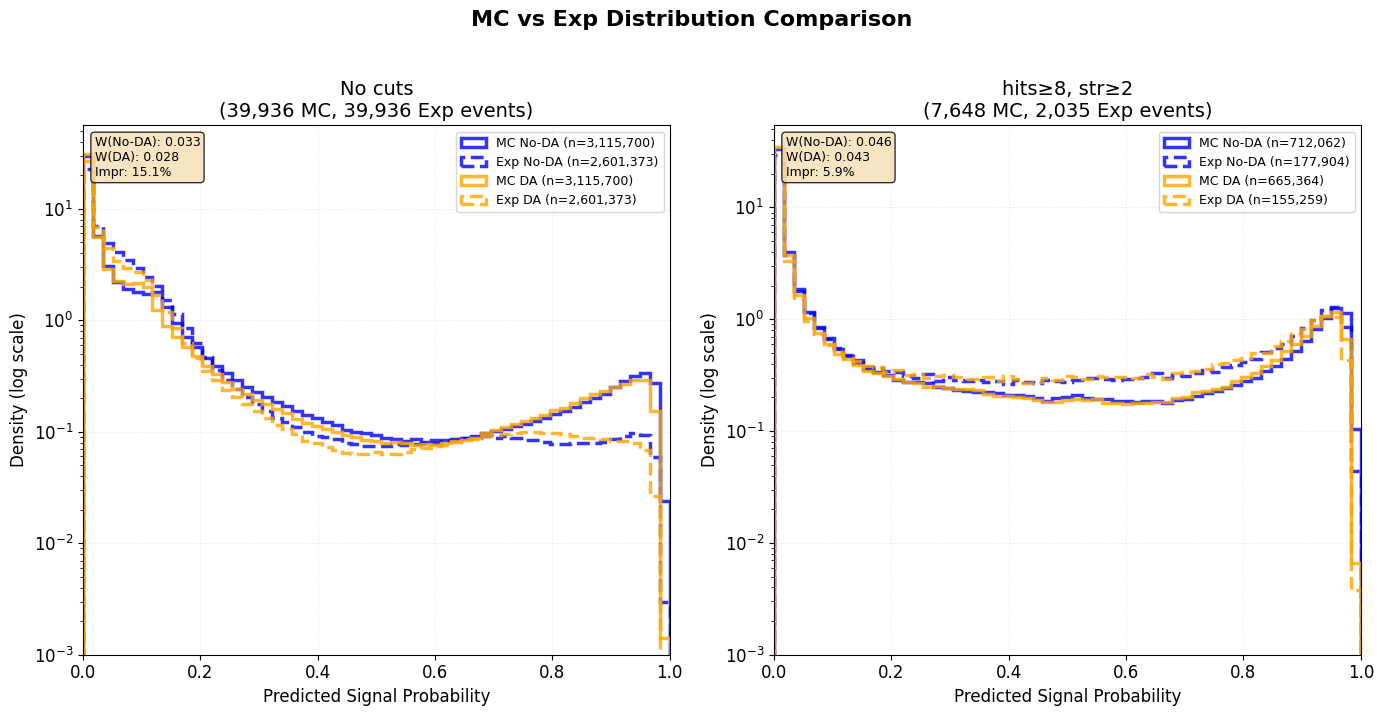


  Cuts (hits, str)   |  W No-DA   |    W DA    |  Improv.   |    N Events    
       (0, 0)        |   0.0328   |   0.0278   |   15.1   % | 39,936 / 39,936
       (8, 2)        |   0.0461   |   0.0434   |    5.9   % | 7,648 / 2,035


In [45]:
def plot_signal_distributions_multi_cuts(result_no_da, result_da,
                                          cuts=[(0, 0), (10, 0), (10, 2)],
                                          save_path=None):
    """
    Compare distributions for multiple (min_hits, min_strings) cuts
    
    Args:
        cuts: List of (min_signal_hits, min_unique_strings) tuples
    """
    
    fig, axes = plt.subplots(1, len(cuts), figsize=(7 * len(cuts), 7))
    if len(cuts) == 1:
        axes = [axes]
    
    bins = np.linspace(0, 1.0, 60)
    all_results = {}
    
    for ax, (min_hits, min_strings) in zip(axes, cuts):
        
        # ============ Filter data ============
        def get_filtered_probs(result, dataset_name, min_hits, min_strings, q_cut=0.0):
            """
            Faster version using list comprehension
            """
            # Event-level filtering
            num_hits = np.array([p.sum() for p in result[dataset_name]["preds"]])
            num_strings = np.array(result[dataset_name]["num_un_strings"])
            
            event_mask = (num_hits >= min_hits) & (num_strings >= min_strings)
            n_events = event_mask.sum()
            
            if not event_mask.any():
                return np.array([]), 0
            
            passing_indices = np.where(event_mask)[0]
            
            # Apply Q cut within each event and collect
            if q_cut > 0:
                probs_list = [
                    result[dataset_name]["probs"][i][result[dataset_name]["x"][i][:, 0] > q_cut]
                    for i in passing_indices
                ]
            else:
                probs_list = [result[dataset_name]["probs"][i] for i in passing_indices]
            
            # Filter out empty arrays and concatenate
            probs_list = [p for p in probs_list if len(p) > 0]
            
            probs = np.concatenate(probs_list) if probs_list else np.array([])
            
            return probs, n_events

        
        mc_no_da, n_mc_no_da = get_filtered_probs(result_no_da, "sig_noise_2020", min_hits, min_strings)
        mc_da, n_mc_da = get_filtered_probs(result_da, "sig_noise_2020", min_hits, min_strings)
        exp_no_da, n_exp_no_da = get_filtered_probs(result_no_da, "exp_data", min_hits, min_strings)
        exp_da, n_exp_da = get_filtered_probs(result_da, "exp_data", min_hits, min_strings)
        
        # ============ Compute Wasserstein ============
        
        w_no_da = wasserstein_distance(mc_no_da, exp_no_da) if len(mc_no_da) > 0 and len(exp_no_da) > 0 else np.nan
        w_da = wasserstein_distance(mc_da, exp_da) if len(mc_da) > 0 and len(exp_da) > 0 else np.nan
        
        all_results[(min_hits, min_strings)] = {
            'w_no_da': w_no_da, 'w_da': w_da,
            'n_mc_no_da': n_mc_no_da, 'n_exp_no_da': n_exp_no_da,
            'n_mc_da': n_mc_da, 'n_exp_da': n_exp_da,
        }
        
        # ============ Plot ============
        
        if len(mc_no_da) > 0:
            ax.hist(mc_no_da, bins=bins, label=f'MC No-DA (n={len(mc_no_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='blue', linestyle='-', alpha=0.8)
        if len(exp_no_da) > 0:
            ax.hist(exp_no_da, bins=bins, label=f'Exp No-DA (n={len(exp_no_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='blue', linestyle='--', alpha=0.8)
        if len(mc_da) > 0:
            ax.hist(mc_da, bins=bins, label=f'MC DA (n={len(mc_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='orange', linestyle='-', alpha=0.8)
        if len(exp_da) > 0:
            ax.hist(exp_da, bins=bins, label=f'Exp DA (n={len(exp_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='orange', linestyle='--', alpha=0.8)
        
        # ============ Styling ============
        
        cut_str = 'No cuts' if min_hits == 0 and min_strings == 0 else f'hits≥{min_hits}, str≥{min_strings}'
        ax.set_xlabel('Predicted Signal Probability', fontsize=12)
        ax.set_ylabel('Density (log scale)', fontsize=12)
        ax.set_title(f'{cut_str}\n({n_mc_da:,} MC, {n_exp_da:,} Exp events)', fontsize=14)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_xlim(0, 1.0)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
        
        # Wasserstein annotation
        if not np.isnan(w_no_da) and not np.isnan(w_da):
            improvement = (w_no_da - w_da) / w_no_da * 100
            ax.text(0.02, 0.98, 
                    f'W(No-DA): {w_no_da:.3f}\nW(DA): {w_da:.3f}\nImpr: {improvement:.1f}%',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.suptitle('MC vs Exp Distribution Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    # Print summary
    print("\n" + "=" * 80)
    print(f"{'Cuts (hits, str)':^20} | {'W No-DA':^10} | {'W DA':^10} | {'Improv.':^10} | {'N Events':^15}")
    print("=" * 80)
    for cut, res in all_results.items():
        imp = (res['w_no_da'] - res['w_da']) / res['w_no_da'] * 100 if not np.isnan(res['w_no_da']) else np.nan
        print(f"{str(cut):^20} | {res['w_no_da']:^10.4f} | {res['w_da']:^10.4f} | {imp:^9.1f}% | {res['n_mc_da']:,} / {res['n_exp_da']:,}")
    print("=" * 80)
    
    return all_results


# Usage
results = plot_signal_distributions_multi_cuts(
    result_no_da, 
    result_da,
    cuts=[(0, 0), (8, 2)],
    save_path=output_dir / "signal_distributions_multi_cuts.png"
)


Saved: plots/signal_distributions_multi_cuts.png


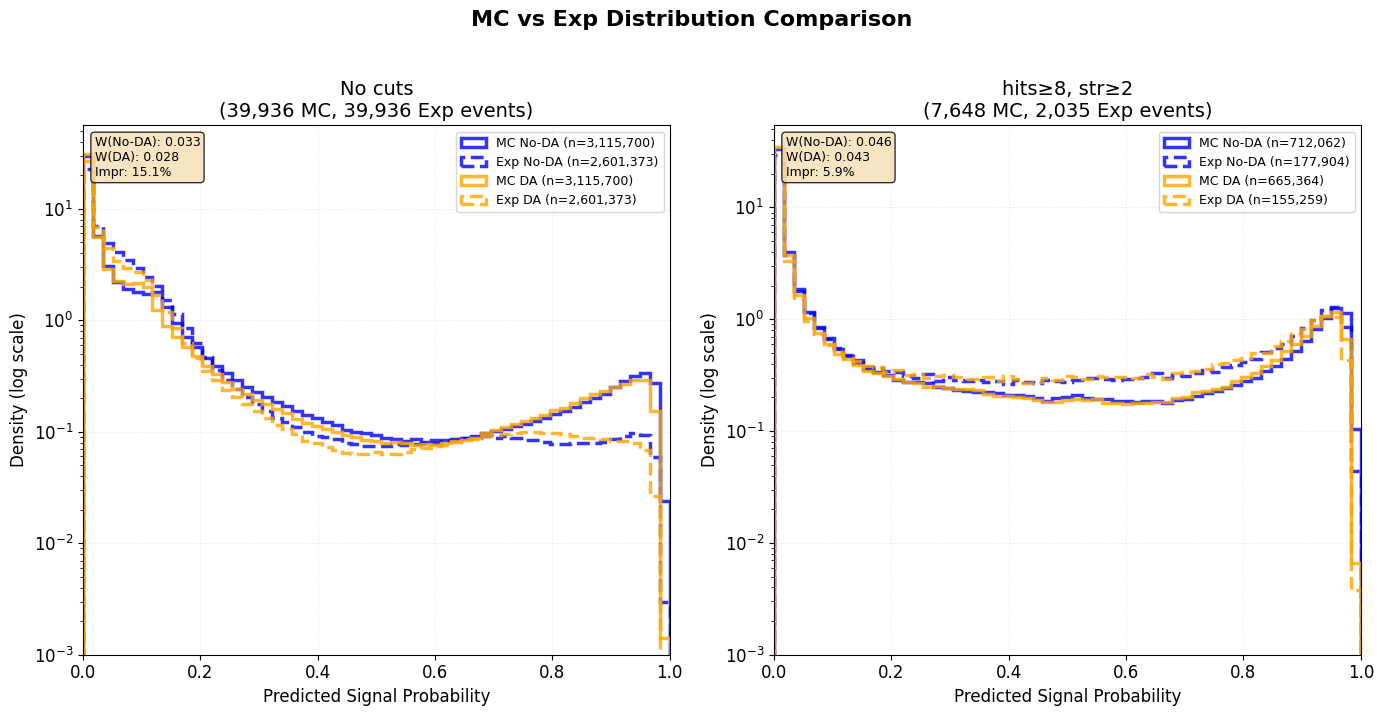


  Cuts (hits, str)   |  W No-DA   |    W DA    |  Improv.   |    N Events    
       (0, 0)        |   0.0328   |   0.0278   |   15.1   % | 39,936 / 39,936
       (8, 2)        |   0.0461   |   0.0434   |    5.9   % | 7,648 / 2,035


In [46]:
# Usage
results = plot_signal_distributions_multi_cuts(
    result_no_da, 
    result_da,
    cuts=[(0, 0), (8, 2)],
    save_path=output_dir / "signal_distributions_multi_cuts.png"
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp
from itertools import product
import pandas as pd

def grid_search_best_cuts(result_no_da, result_da, 
                          q_cuts=[0, 0.5, 1.0, 1.5, 2.0],
                          num_hits_hits=[(0, 0), (8, 2), (10, 3)],
                          save_path=None):
    """
    Search over 2D grid of cuts to find where MC and Exp distributions are closest
    
    Returns DataFrame with Wasserstein distance for each combination
    """
    
    results = []
    
    # Create all combinations
    combinations = list(product(q_cuts, num_hits_hits))
    
    print(f"Testing {len(combinations)} combinations...")
    
    for q_cut, (min_hits, min_strings) in tqdm(combinations):
        
        # ============ Apply cuts for No DA ============
        
        # Per-event filtering
        num_strings_mc_no_da = np.array(result_no_da["sig_noise_2020"]["num_un_strings"])
        num_strings_exp_no_da = np.array(result_no_da["exp_data"]["num_un_strings"])
        
        num_hits_mc_no_da = np.array([p.sum() for p in result_no_da["sig_noise_2020"]["preds"]])
        num_hits_exp_no_da = np.array([p.sum() for p in result_no_da["exp_data"]["preds"]])
        
        # Event masks
        mask_mc_no_da = (num_strings_mc_no_da >= min_strings) & (num_hits_mc_no_da >= min_hits)
        mask_exp_no_da = (num_strings_exp_no_da >= min_strings) & (num_hits_exp_no_da >= min_hits)
        
        # Get probabilities for passing events
        if mask_mc_no_da.any() and mask_exp_no_da.any():
            probs_mc_no_da = np.concatenate([
                result_no_da["sig_noise_2020"]["probs"][i] 
                for i in np.where(mask_mc_no_da)[0]
            ])
            probs_exp_no_da = np.concatenate([
                result_no_da["exp_data"]["probs"][i] 
                for i in np.where(mask_exp_no_da)[0]
            ])
            
            # Apply Q cut on hit level
            if q_cut > 0:
                q_mc_no_da = np.concatenate([
                    result_no_da["sig_noise_2020"]["x"][i][:, 0] 
                    for i in np.where(mask_mc_no_da)[0]
                ])
                q_exp_no_da = np.concatenate([
                    result_no_da["exp_data"]["x"][i][:, 0] 
                    for i in np.where(mask_exp_no_da)[0]
                ])
                
                probs_mc_no_da = probs_mc_no_da[q_mc_no_da > q_cut]
                probs_exp_no_da = probs_exp_no_da[q_exp_no_da > q_cut]
        else:
            probs_mc_no_da = np.array([])
            probs_exp_no_da = np.array([])
        
        # ============ Apply cuts for DA ============
        
        num_strings_mc_da = np.array(result_da["sig_noise_2020"]["num_un_strings"])
        num_strings_exp_da = np.array(result_da["exp_data"]["num_un_strings"])
        
        num_hits_mc_da = np.array([p.sum() for p in result_da["sig_noise_2020"]["preds"]])
        num_hits_exp_da = np.array([p.sum() for p in result_da["exp_data"]["preds"]])
        
        mask_mc_da = (num_strings_mc_da >= min_strings) & (num_hits_mc_da >= min_hits)
        mask_exp_da = (num_strings_exp_da >= min_strings) & (num_hits_exp_da >= min_hits)
        
        if mask_mc_da.any() and mask_exp_da.any():
            probs_mc_da = np.concatenate([
                result_da["sig_noise_2020"]["probs"][i] 
                for i in np.where(mask_mc_da)[0]
            ])
            probs_exp_da = np.concatenate([
                result_da["exp_data"]["probs"][i] 
                for i in np.where(mask_exp_da)[0]
            ])
            
            if q_cut > 0:
                q_mc_da = np.concatenate([
                    result_da["sig_noise_2020"]["x"][i][:, 0] 
                    for i in np.where(mask_mc_da)[0]
                ])
                q_exp_da = np.concatenate([
                    result_da["exp_data"]["x"][i][:, 0] 
                    for i in np.where(mask_exp_da)[0]
                ])
                
                probs_mc_da = probs_mc_da[q_mc_da > q_cut]
                probs_exp_da = probs_exp_da[q_exp_da > q_cut]
        else:
            probs_mc_da = np.array([])
            probs_exp_da = np.array([])
        
        # ============ Compute metrics ============
        
        if len(probs_mc_no_da) > 100 and len(probs_exp_no_da) > 100:
            w_no_da = wasserstein_distance(probs_mc_no_da, probs_exp_no_da)
            ks_no_da, _ = ks_2samp(probs_mc_no_da, probs_exp_no_da)
        else:
            w_no_da = np.nan
            ks_no_da = np.nan
        
        if len(probs_mc_da) > 100 and len(probs_exp_da) > 100:
            w_da = wasserstein_distance(probs_mc_da, probs_exp_da)
            ks_da, _ = ks_2samp(probs_mc_da, probs_exp_da)
        else:
            w_da = np.nan
            ks_da = np.nan
        
        results.append({
            'q_cut': q_cut,
            'min_strings': min_strings,
            'min_hits': min_hits,
            'w_no_da': w_no_da,
            'w_da': w_da,
            'ks_no_da': ks_no_da,
            'ks_da': ks_da,
            'n_mc_no_da': len(probs_mc_no_da),
            'n_exp_no_da': len(probs_exp_no_da),
            'n_mc_da': len(probs_mc_da),
            'n_exp_da': len(probs_exp_da),
            'n_events_mc': mask_mc_da.sum(),
            'n_events_exp': mask_exp_da.sum(),
        })
    
    df = pd.DataFrame(results)
    
    # Compute improvement
    df['w_improvement'] = (df['w_no_da'] - df['w_da']) / df['w_no_da'] * 100
    df['ks_improvement'] = (df['ks_no_da'] - df['ks_da']) / df['ks_no_da'] * 100
    
    return df


def plot_grid_search_results(df, metric='w_da', save_path=None):
    """
    Plot heatmaps of grid search results
    """
    
    q_cuts = sorted(df['q_cut'].unique())
    num_strings = sorted(df['min_strings'].unique())
    num_hits = sorted(df['min_hits'].unique())
    
    # Create subplots for each Q cut
    n_q = len(q_cuts)
    fig, axes = plt.subplots(2, n_q, figsize=(5 * n_q, 10))
    
    for i, q_cut in enumerate(q_cuts):
        df_q = df[df['q_cut'] == q_cut]
        
        # ============ No DA heatmap ============
        ax = axes[0, i]
        
        # Pivot for heatmap
        pivot_no_da = df_q.pivot(index='min_strings', columns='min_hits', values='w_no_da')
        
        im = ax.imshow(pivot_no_da.values, cmap='RdYlGn_r', aspect='auto')
        
        # Labels
        ax.set_xticks(range(len(num_hits)))
        ax.set_xticklabels(num_hits)
        ax.set_yticks(range(len(num_strings)))
        ax.set_yticklabels(num_strings)
        ax.set_xlabel('min_hits', fontsize=12)
        ax.set_ylabel('min_strings', fontsize=12)
        ax.set_title(f'No DA\nQ > {q_cut}', fontsize=14, fontweight='bold')
        
        # Add values
        for ii in range(len(num_strings)):
            for jj in range(len(num_hits)):
                val = pivot_no_da.values[ii, jj]
                if not np.isnan(val):
                    ax.text(jj, ii, f'{val:.3f}', ha='center', va='center', 
                            fontsize=9, color='black')
        
        plt.colorbar(im, ax=ax, label='Wasserstein')
        
        # ============ DA heatmap ============
        ax = axes[1, i]
        
        pivot_da = df_q.pivot(index='min_strings', columns='min_hits', values='w_da')
        
        im = ax.imshow(pivot_da.values, cmap='RdYlGn_r', aspect='auto')
        
        ax.set_xticks(range(len(num_hits)))
        ax.set_xticklabels(num_hits)
        ax.set_yticks(range(len(num_strings)))
        ax.set_yticklabels(num_strings)
        ax.set_xlabel('min_hits', fontsize=12)
        ax.set_ylabel('min_strings', fontsize=12)
        ax.set_title(f'With DA\nQ > {q_cut}', fontsize=14, fontweight='bold')
        
        for ii in range(len(num_strings)):
            for jj in range(len(num_hits)):
                val = pivot_da.values[ii, jj]
                if not np.isnan(val):
                    ax.text(jj, ii, f'{val:.3f}', ha='center', va='center', 
                            fontsize=9, color='black')
        
        plt.colorbar(im, ax=ax, label='Wasserstein')
    
    plt.suptitle('MC-Exp Distribution Distance (Wasserstein) by Cuts\nLower = Better Alignment', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


def plot_improvement_heatmap(df, save_path=None):
    """
    Plot improvement (DA vs No DA) heatmap
    """
    
    q_cuts = sorted(df['q_cut'].unique())
    num_strings = sorted(df['min_strings'].unique())
    num_hits = sorted(df['min_hits'].unique())
    
    n_q = len(q_cuts)
    fig, axes = plt.subplots(1, n_q, figsize=(5 * n_q, 5))
    
    if n_q == 1:
        axes = [axes]
    
    for i, q_cut in enumerate(q_cuts):
        ax = axes[i]
        df_q = df[df['q_cut'] == q_cut]
        
        pivot = df_q.pivot(index='min_strings', columns='min_hits', values='w_improvement')
        
        im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=-10, vmax=50)
        
        ax.set_xticks(range(len(num_hits)))
        ax.set_xticklabels(num_hits)
        ax.set_yticks(range(len(num_strings)))
        ax.set_yticklabels(num_strings)
        ax.set_xlabel('min_hits', fontsize=12)
        ax.set_ylabel('min_strings', fontsize=12)
        ax.set_title(f'Q > {q_cut}', fontsize=14, fontweight='bold')
        
        for ii in range(len(num_strings)):
            for jj in range(len(num_hits)):
                val = pivot.values[ii, jj]
                if not np.isnan(val):
                    ax.text(jj, ii, f'{val:.1f}%', ha='center', va='center', 
                            fontsize=9, color='black' if abs(val) < 30 else 'white')
        
        plt.colorbar(im, ax=ax, label='Improvement %')
    
    plt.suptitle('DA Improvement over No DA (%)\nHigher = DA Helps More', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


def print_best_cuts(df, top_n=10):
    """
    Print best cut combinations
    """
    
    print("\n" + "=" * 120)
    print("TOP CUTS FOR BEST MC-EXP ALIGNMENT (DA Model)")
    print("=" * 120)
    
    df_valid = df.dropna(subset=['w_da'])
    df_sorted = df_valid.sort_values('w_da')
    
    print(f"\n{'Rank':^5} | {'Q':^5} | {'Str':^5} | {'Hits':^5} | {'W(DA)':^10} | {'W(NoDA)':^10} | {'Impr%':^8} | {'Events MC':^12} | {'Events Exp':^12}")
    print("-" * 120)
    
    for rank, (_, row) in enumerate(df_sorted.head(top_n).iterrows(), 1):
        print(f"{rank:^5} | {row['q_cut']:^5.1f} | {row['min_strings']:^5.0f} | {row['min_hits']:^5.0f} | "
              f"{row['w_da']:^10.4f} | {row['w_no_da']:^10.4f} | {row['w_improvement']:^7.1f}% | "
              f"{row['n_events_mc']:^12,} | {row['n_events_exp']:^12,}")
    
    print("\n" + "=" * 120)
    print("TOP CUTS FOR BEST DA IMPROVEMENT")
    print("=" * 120)
    
    df_sorted_imp = df_valid.sort_values('w_improvement', ascending=False)
    
    print(f"\n{'Rank':^5} | {'Q':^5} | {'Str':^5} | {'Hits':^5} | {'W(DA)':^10} | {'W(NoDA)':^10} | {'Impr%':^8} | {'Events MC':^12} | {'Events Exp':^12}")
    print("-" * 120)
    
    for rank, (_, row) in enumerate(df_sorted_imp.head(top_n).iterrows(), 1):
        print(f"{rank:^5} | {row['q_cut']:^5.1f} | {row['min_strings']:^5.0f} | {row['min_hits']:^5.0f} | "
              f"{row['w_da']:^10.4f} | {row['w_no_da']:^10.4f} | {row['w_improvement']:^7.1f}% | "
              f"{row['n_events_mc']:^12,} | {row['n_events_exp']:^12,}")
    
    print("=" * 120)


def plot_best_distributions(result_no_da, result_da, df, top_n=4, save_path=None):
    """
    Plot distributions for top N best cuts
    """
    
    df_valid = df.dropna(subset=['w_da'])
    df_sorted = df_valid.sort_values('w_da').head(top_n)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    bins = np.linspace(0, 1.0, 50)
    
    for idx, (_, row) in enumerate(df_sorted.iterrows()):
        ax = axes[idx]
        
        q_cut = row['q_cut']
        min_strings = int(row['min_strings'])
        min_hits = int(row['min_hits'])
        
        # Get filtered data
        def get_filtered_probs(result, dataset, q_cut, min_strings, min_hits):
            num_strings = np.array(result[dataset]["num_un_strings"])
            num_hits_arr = np.array([p.sum() for p in result[dataset]["preds"]])
            
            mask = (num_strings >= min_strings) & (num_hits_arr >= min_hits)
            
            if not mask.any():
                return np.array([])
            
            probs = np.concatenate([result[dataset]["probs"][i] for i in np.where(mask)[0]])
            
            if q_cut > 0:
                q_vals = np.concatenate([result[dataset]["x"][i][:, 0] for i in np.where(mask)[0]])
                probs = probs[q_vals > q_cut]
            
            return probs
        
        mc_no_da = get_filtered_probs(result_no_da, "sig_noise_2020", q_cut, min_strings, min_hits)
        exp_no_da = get_filtered_probs(result_no_da, "exp_data", q_cut, min_strings, min_hits)
        mc_da = get_filtered_probs(result_da, "sig_noise_2020", q_cut, min_strings, min_hits)
        exp_da = get_filtered_probs(result_da, "exp_data", q_cut, min_strings, min_hits)
        
        # Plot
        if len(mc_no_da) > 0:
            n_events = mc_no_da.shape[0]
            exp_n_events = exp_no_da.shape[0]
            ax.hist(mc_no_da, bins=bins, density=True, histtype='step', 
                    linewidth=2.5, color='blue', linestyle='-', alpha=0.8,
                    label=f'MC No-DA (n={n_events:,hits})')
        if len(exp_no_da) > 0:
            ax.hist(exp_no_da, bins=bins, density=True, histtype='step', 
                    linewidth=2.5, color='blue', linestyle='--', alpha=0.8,
                    label=f'Exp No-DA (n={exp_n_events:,hits})')
        if len(mc_da) > 0:
            ax.hist(mc_da, bins=bins, density=True, histtype='step', 
                    linewidth=2.5, color='orange', linestyle='-', alpha=0.8,
                    label=f'MC DA (n={n_events:,hits})')
        if len(exp_da) > 0:
            ax.hist(exp_da, bins=bins, density=True, histtype='step', 
                    linewidth=2.5, color='orange', linestyle='--', alpha=0.8,
                    label=f'Exp DA (n={exp_n_events:,hits})')
        
        ax.set_xlabel('Predicted Signal Probability', fontsize=12)
        ax.set_ylabel('Normalized Density', fontsize=12)
        ax.set_title(f'Q>{q_cut}, str≥{min_strings}, hits≥{min_hits}\n'
                     f'W(DA)={row["w_da"]:.4f}, Impr={row["w_improvement"]:.1f}%',
                     fontsize=12, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_xlim(0, 1)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
    
    plt.suptitle('Best Cut Combinations for MC-Exp Alignment', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()


# ============ RUN GRID SEARCH ============

# Run grid search
df_results = grid_search_best_cuts(
    result_no_da, 
    result_da,
    q_cuts=[0, 0.5, 1.0, 1.5],
)

# Print best cuts
print_best_cuts(df_results, top_n=10)

# Plot heatmaps
plot_grid_search_results(
    df_results, 
    save_path=output_dir / "grid_search_wasserstein.png"
)

# Plot improvement heatmap
# plot_improvement_heatmap(
#     df_results,
#     save_path=output_dir / "grid_search_improvement.png"
# )

# Plot best distributions
plot_best_distributions(
    result_no_da, 
    result_da, 
    df_results, 
    top_n=4,
    save_path=output_dir / "best_cuts_distributions.png"
)

# Save results to CSV
df_results.to_csv(output_dir / "grid_search_results.csv", index=False)
print(f"\nResults saved to {output_dir / 'grid_search_results.csv'}")


SyntaxError: invalid syntax (531375194.py, line 356)

Saved: plots/signal_distributions_multi_cuts.png


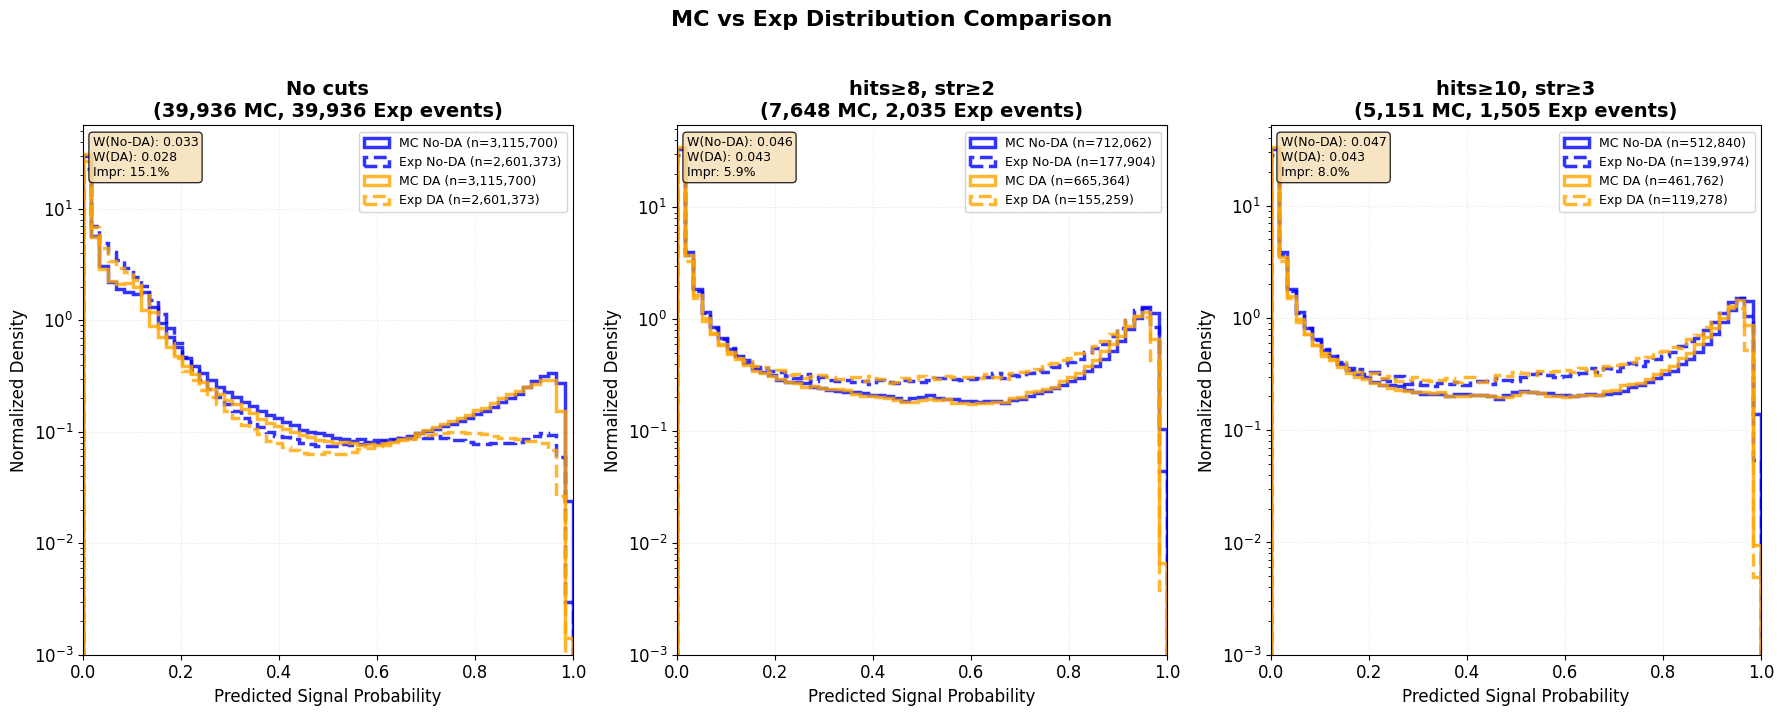


  Cuts (hits, str)   |  W No-DA   |    W DA    |  Improv.   |    N Events    
       (0, 0)        |   0.0328   |   0.0278   |   15.1   % | 39,936 / 39,936
       (8, 2)        |   0.0461   |   0.0434   |    5.9   % | 7,648 / 2,035
      (10, 3)        |   0.0465   |   0.0428   |    8.0   % | 5,151 / 1,505


In [49]:
def plot_signal_distributions_multi_cuts(result_no_da, result_da,
                                          cuts=[(0, 0), (10, 0), (10, 2)],
                                          save_path=None):
    """
    Compare distributions for multiple (min_hits, min_strings) cuts
    
    Args:
        cuts: List of (min_signal_hits, min_unique_strings) tuples
    """
    
    fig, axes = plt.subplots(1, len(cuts), figsize=(6 * len(cuts), 7))
    if len(cuts) == 1:
        axes = [axes]
    
    bins = np.linspace(0, 1.0, 60)
    all_results = {}
    
    for ax, (min_hits, min_strings) in zip(axes, cuts):
        
        # ============ Filter data ============
        
        def get_filtered_probs(result, dataset_name, min_hits, min_strings):
            num_hits = np.array([p.sum() for p in result[dataset_name]["preds"]])
            num_strings = np.array(result[dataset_name]["num_un_strings"])
            mask = (num_hits >= min_hits) & (num_strings >= min_strings)
            
            if mask.any():
                probs = np.concatenate([
                    result[dataset_name]["probs"][i] 
                    for i in np.where(mask)[0]
                ])
            else:
                probs = np.array([])
            
            return probs, mask.sum()
        
        mc_no_da, n_mc_no_da = get_filtered_probs(result_no_da, "sig_noise_2020", min_hits, min_strings)
        mc_da, n_mc_da = get_filtered_probs(result_da, "sig_noise_2020", min_hits, min_strings)
        exp_no_da, n_exp_no_da = get_filtered_probs(result_no_da, "exp_data", min_hits, min_strings)
        exp_da, n_exp_da = get_filtered_probs(result_da, "exp_data", min_hits, min_strings)
        
        # ============ Compute Wasserstein ============
        
        w_no_da = wasserstein_distance(mc_no_da, exp_no_da) if len(mc_no_da) > 0 and len(exp_no_da) > 0 else np.nan
        w_da = wasserstein_distance(mc_da, exp_da) if len(mc_da) > 0 and len(exp_da) > 0 else np.nan
        
        all_results[(min_hits, min_strings)] = {
            'w_no_da': w_no_da, 'w_da': w_da,
            'n_mc_no_da': n_mc_no_da, 'n_exp_no_da': n_exp_no_da,
            'n_mc_da': n_mc_da, 'n_exp_da': n_exp_da,
        }
        
        # ============ Plot ============
        
        if len(mc_no_da) > 0:
            ax.hist(mc_no_da, bins=bins, label=f'MC No-DA (n={len(mc_no_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='blue', linestyle='-', alpha=0.8)
        if len(exp_no_da) > 0:
            ax.hist(exp_no_da, bins=bins, label=f'Exp No-DA (n={len(exp_no_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='blue', linestyle='--', alpha=0.8)
        if len(mc_da) > 0:
            ax.hist(mc_da, bins=bins, label=f'MC DA (n={len(mc_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='orange', linestyle='-', alpha=0.8)
        if len(exp_da) > 0:
            ax.hist(exp_da, bins=bins, label=f'Exp DA (n={len(exp_da):,})',
                    density=True, histtype='step', linewidth=2.5, color='orange', linestyle='--', alpha=0.8)
        
        # ============ Styling ============
        
        cut_str = 'No cuts' if min_hits == 0 and min_strings == 0 else f'hits≥{min_hits}, str≥{min_strings}'
        ax.set_xlabel('Predicted Signal Probability', fontsize=12)
        ax.set_ylabel('Normalized Density', fontsize=12)
        ax.set_title(f'{cut_str}\n({n_mc_da:,} MC, {n_exp_da:,} Exp events)', fontsize=14, fontweight='bold')
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.3, linestyle=':')
        ax.set_xlim(0, 1.0)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
        
        # Wasserstein annotation
        if not np.isnan(w_no_da) and not np.isnan(w_da):
            improvement = (w_no_da - w_da) / w_no_da * 100
            ax.text(0.02, 0.98, 
                    f'W(No-DA): {w_no_da:.3f}\nW(DA): {w_da:.3f}\nImpr: {improvement:.1f}%',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.suptitle('MC vs Exp Distribution Comparison', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    # Print summary
    print("\n" + "=" * 80)
    print(f"{'Cuts (hits, str)':^20} | {'W No-DA':^10} | {'W DA':^10} | {'Improv.':^10} | {'N Events':^15}")
    print("=" * 80)
    for cut, res in all_results.items():
        imp = (res['w_no_da'] - res['w_da']) / res['w_no_da'] * 100 if not np.isnan(res['w_no_da']) else np.nan
        print(f"{str(cut):^20} | {res['w_no_da']:^10.4f} | {res['w_da']:^10.4f} | {imp:^9.1f}% | {res['n_mc_da']:,} / {res['n_exp_da']:,}")
    print("=" * 80)
    
    return all_results


# Usage
results = plot_signal_distributions_multi_cuts(
    result_no_da, 
    result_da,
    cuts=[(0, 0), (8, 2), (10, 3)],
    save_path=output_dir / "signal_distributions_multi_cuts.png"
)

Saved: plots/noise_sig_comparison_density_grid.png


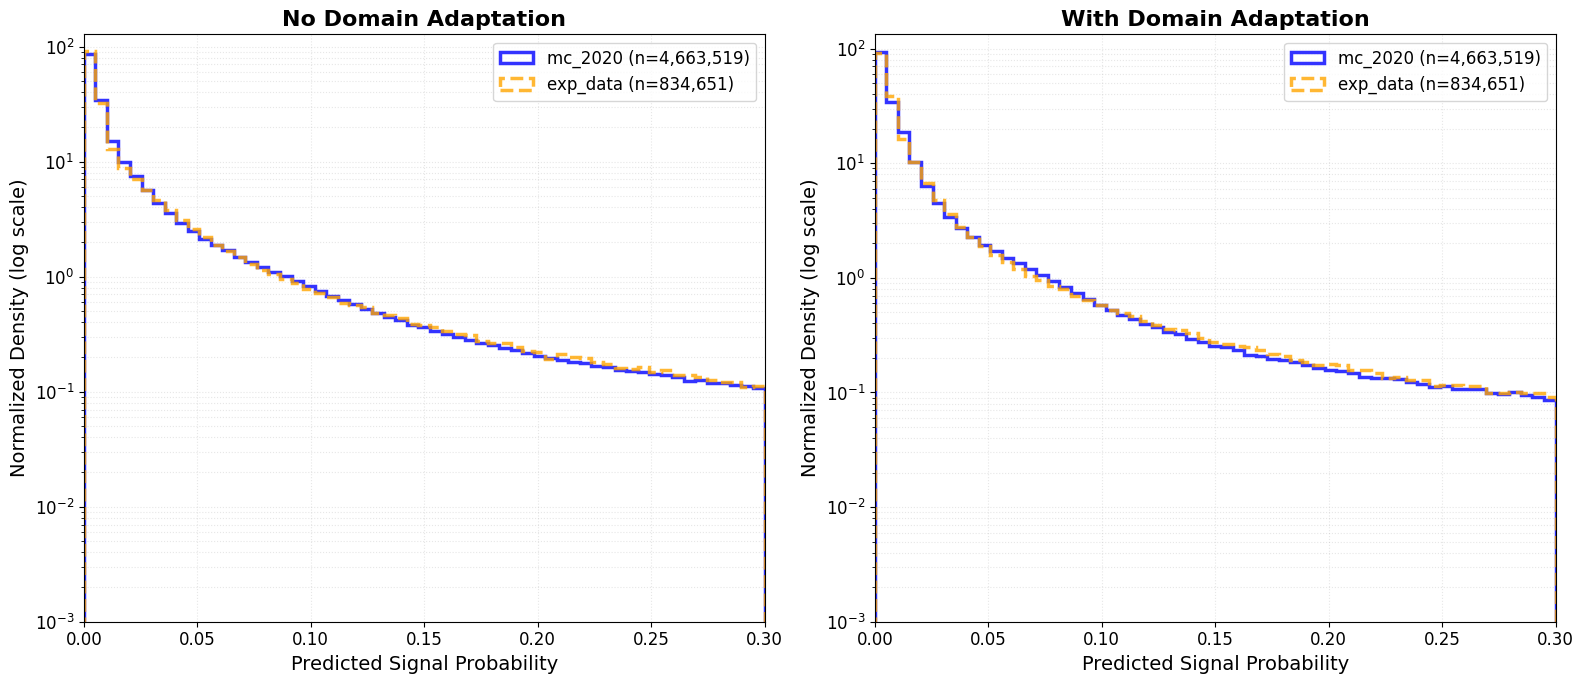

In [14]:
def plot_signal_noise_density_grid(preds_no_da, labels_no_da, preds_da, labels_da,
                                   preds_unlabeled_no_da, preds_unlabeled_da, save_path=None):
    """
    2 plots comparing MC vs Exp distributions
    Left: No-DA, Right: With DA
    Each plot shows MC (all hits) vs Exp (all hits)
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    bins = np.linspace(0, 0.3, 60)
    
    # Get dataset names
    mc_name = list(preds_no_da.keys())[0] if preds_no_da else None
    exp_name = list(preds_unlabeled_no_da.keys())[0] if preds_unlabeled_no_da else None
    
    # Rename sig_noise_2020 to mc_2020 for display
    mc_display_name = mc_name.replace('sig_noise', 'mc') if mc_name else 'MC'
    
    # Left plot: No-DA (MC vs Exp, all hits)
    if mc_name and exp_name:
        ax = axes[0]
        mc_preds = preds_no_da[mc_name]
        exp_preds = preds_unlabeled_no_da[exp_name]
        
        ax.hist(mc_preds, bins=bins, label=f'{mc_display_name} (n={len(mc_preds):,})', 
                density=True, histtype='step', color='blue', linewidth=2.5, alpha=0.8)
        ax.hist(exp_preds, bins=bins, label=f'{exp_name} (n={len(exp_preds):,})', 
                density=True, histtype='step', color='orange', linewidth=2.5, alpha=0.8, linestyle='--')
        
        ax.set_xlabel('Predicted Signal Probability', fontsize=14)
        ax.set_ylabel('Normalized Density (log scale)', fontsize=14)
        ax.set_title('No Domain Adaptation', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3, which='both', linestyle=':')
        ax.set_xlim(0, 0.3)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
    
    # Right plot: DA (MC vs Exp, all hits)
    if mc_name and exp_name:
        ax = axes[1]
        mc_preds = preds_da[mc_name]
        exp_preds = preds_unlabeled_da[exp_name]
        
        ax.hist(mc_preds, bins=bins, label=f'{mc_display_name} (n={len(mc_preds):,})', 
                density=True, histtype='step', color='blue', linewidth=2.5, alpha=0.8)
        ax.hist(exp_preds, bins=bins, label=f'{exp_name} (n={len(exp_preds):,})', 
                density=True, histtype='step', color='orange', linewidth=2.5, alpha=0.8, linestyle='--')
        
        ax.set_xlabel('Predicted Signal Probability', fontsize=14)
        ax.set_ylabel('Normalized Density (log scale)', fontsize=14)
        ax.set_title('With Domain Adaptation', fontsize=16, fontweight='bold')
        ax.legend(fontsize=12)
        ax.grid(alpha=0.3, which='both', linestyle=':')
        ax.set_xlim(0, 0.3)
        ax.set_yscale('log')
        ax.set_ylim(bottom=1e-3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Generate plot
plot_signal_noise_density_grid(
    preds_no_da, labels_no_da, preds_da, labels_da,
    preds_unlabeled_no_da, preds_unlabeled_da,
    output_dir / "noise_sig_comparison_density_grid.png"
)


In [15]:
# len(result_no_da["sig_noise_2020"]["hidden_states"])
312 * 128

39936

In [50]:
from sklearn.decomposition import PCA

def fast_umap(data, n_samples=20000, pca_dims=50):
    """Fast UMAP with PCA preprocessing"""
    
    # Subsample if needed
    if len(data) > n_samples:
        idx = np.random.choice(len(data), n_samples, replace=False)
        data = data[idx]
    
    # PCA first
    pca = PCA(n_components=min(pca_dims, data.shape[1]))
    data_pca = pca.fit_transform(data)
    
    # Fast UMAP settings
    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        low_memory=True,
        n_jobs=-1,
    )
    
    return reducer.fit_transform(data_pca)


(39936, 512)
(39936, 512)
(39936, 512)
(39936, 512)
Computing UMAP for No-DA model...
Computing UMAP for DA model...


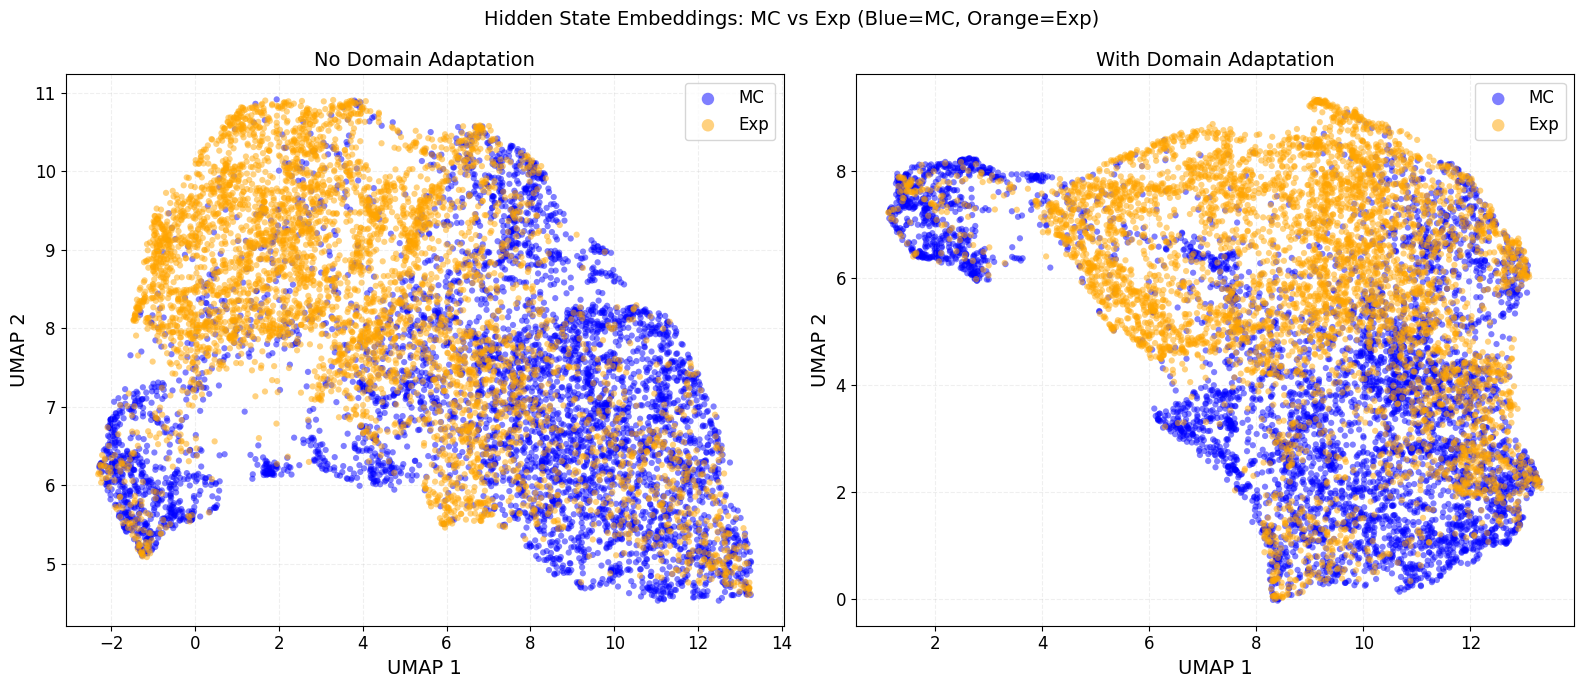

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA


def fast_umap(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    """Fast UMAP with PCA preprocessing to reduce dimensionality first."""
    # PCA to reduce noise and speed up UMAP
    pca = PCA(n_components=min(50, data.shape[1]))  # Cap at 50 components
    data_pca = pca.fit_transform(data)
    
    # UMAP on PCA-reduced data
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric='euclidean',
        low_memory=True,
        n_jobs=-1
    )
    return reducer.fit_transform(data_pca)

def plot_umap_comparison(
    result_no_da,
    result_da,
    max_samples=5000,
    save_path=None,
    n_events=200,          # Increased default for better stats
):
    """
    UMAP visualization: Compare hidden states (MC vs Exp) with/without DA.
    Uses PCA + UMAP for faster, cleaner embeddings.
    """

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    bs = 128  # Batch size from hidden states


    # --- Step 1: Extract and flatten hidden states ---
    def flatten_hidden(dataset, key):
        states = dataset[key]["hidden_states"]
        print(states.shape)
        return states
        # Take first `n_events` events, reshape to (N_hits, 512)
        #flat = [h.reshape(-1, h.shape[-1]) for h in states[:n_events // bs]]
        # return np.vstack(flat) if flat else np.zeros((0, 512))

    hidden_mc_no_da = flatten_hidden(result_no_da, "sig_noise_2020")
    hidden_exp_no_da = flatten_hidden(result_no_da, "exp_data")
    hidden_mc_da = flatten_hidden(result_da, "sig_noise_2020")
    hidden_exp_da = flatten_hidden(result_da, "exp_data")

    # --- Step 2: Subsample evenly from MC and Exp ---
    min_class = min(max_samples, len(hidden_mc_no_da), len(hidden_exp_no_da),
                    len(hidden_mc_da), len(hidden_exp_da))


    idx_mc_no = np.random.choice(len(hidden_mc_no_da), min_class, replace=False)
    idx_exp_no = np.random.choice(len(hidden_exp_no_da), min_class, replace=False)
    idx_mc_da = np.random.choice(len(hidden_mc_da), min_class, replace=False)
    idx_exp_da = np.random.choice(len(hidden_exp_da), min_class, replace=False)


    # Combine for each model
    combined_no_da = np.vstack([
        hidden_mc_no_da[idx_mc_no],
        hidden_exp_no_da[idx_exp_no]
    ])
    labels_no_da = np.array(['MC'] * min_class + ['Exp'] * min_class)


    combined_da = np.vstack([
        hidden_mc_da[idx_mc_da],
        hidden_exp_da[idx_exp_da]
    ])
    labels_da = np.array(['MC'] * min_class + ['Exp'] * min_class)

    # --- Step 3: Compute UMAP embeddings ---
    print("Computing UMAP for No-DA model...")
    embedding_no_da = fast_umap(combined_no_da)


    print("Computing UMAP for DA model...")
    embedding_da = fast_umap(combined_da)


    # --- Step 4: Plotting ---
    colors = {'MC': 'blue', 'Exp': 'orange'}
    alphas = {'MC': 0.5, 'Exp': 0.5}
    sizes = {'MC': 20, 'Exp': 20}


    for i, (embedding, labels, title) in enumerate([
        (embedding_no_da, labels_no_da, 'No Domain Adaptation'),
        (embedding_da, labels_da, 'With Domain Adaptation')
    ]):
        ax = axes[i]
        for cls in ['MC', 'Exp']:
            mask = labels == cls
            ax.scatter(
                embedding[mask, 0], embedding[mask, 1],
                c=colors[cls],
                label=f'{cls}',
                alpha=alphas[cls],
                s=sizes[cls],
                edgecolors='none',
                rasterized=True  # Helps with large plots
            )
        ax.set_xlabel('UMAP 1', fontsize=14)
        ax.set_ylabel('UMAP 2', fontsize=14)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=12, markerscale=2, loc='best', frameon=True)
        ax.grid(alpha=0.2, linestyle='--')
        ax.set_aspect('auto')

    plt.suptitle('Hidden State Embeddings: MC vs Exp (Blue=MC, Orange=Exp)',
                fontsize=14, y=0.98)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

# Usage
plot_umap_comparison(
    result_no_da,
    result_da,
    max_samples=5000,
    save_path=output_dir / "umap_comparison.png",
    n_events=300,
)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np


def get_filtered_event_indices(result, min_strings=2, min_hits=8):
    num_strings = np.array(result["num_un_strings"])              # (N_events,)
    hits_per_event = np.array([len(p) for p in result["preds"]])  # (N_events,)

    mask = (num_strings >= min_strings) & (hits_per_event >= min_hits)
    return np.where(mask)[0]

def fast_umap_events(
    data,
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    random_state=42,
):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    pca = PCA(n_components=min(50, data_scaled.shape[1]), random_state=random_state)
    data_pca = pca.fit_transform(data_scaled)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric="cosine",
        low_memory=True,
        n_jobs=-1,
        random_state=random_state,
    )
    return reducer.fit_transform(data_pca)


def plot_umap_events(
    result_no_da,
    result_da,
    max_events_per_class=5000,
    save_path=None,
    min_strings=2,
    min_hits=8,
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- MC / Exp, no-DA ---
    res_mc_no  = result_no_da["sig_noise_2020"]
    res_exp_no = result_no_da["exp_data"]

    # --- MC / Exp, DA ---
    res_mc_da  = result_da["sig_noise_2020"]
    res_exp_da = result_da["exp_data"]

    # индексы событий по фильтрам
    idx_mc_no  = get_filtered_event_indices(res_mc_no,  min_strings, min_hits)
    idx_exp_no = get_filtered_event_indices(res_exp_no, min_strings, min_hits)
    idx_mc_da  = get_filtered_event_indices(res_mc_da,  min_strings, min_hits)
    idx_exp_da = get_filtered_event_indices(res_exp_da, min_strings, min_hits)

    # берём скрытые векторы событий
    h_mc_no  = res_mc_no["hidden_states"][idx_mc_no]
    h_exp_no = res_exp_no["hidden_states"][idx_exp_no]
    h_mc_da  = res_mc_da["hidden_states"][idx_mc_da]
    h_exp_da = res_exp_da["hidden_states"][idx_exp_da]

    print("Hidden shapes after event filters:")
    print("MC no-DA :", h_mc_no.shape)
    print("Exp no-DA:", h_exp_no.shape)
    print("MC DA    :", h_mc_da.shape)
    print("Exp DA   :", h_exp_da.shape)

    # выравниваем число событий на класс и не превышаем max_events_per_class
    max_n = min(
        max_events_per_class,
        len(h_mc_no), len(h_exp_no),
        len(h_mc_da), len(h_exp_da)
    )
    rng = np.random.default_rng(42)

    def subsample(h):
        if len(h) > max_n:
            idx = rng.choice(len(h), max_n, replace=False)
            return h[idx]
        return h

    h_mc_no  = subsample(h_mc_no)
    h_exp_no = subsample(h_exp_no)
    h_mc_da  = subsample(h_mc_da)
    h_exp_da = subsample(h_exp_da)

    # стэкаем для двух моделей
    h_no_da = np.vstack([h_mc_no, h_exp_no])
    y_no_da = np.array(["MC"] * len(h_mc_no) + ["Exp"] * len(h_exp_no))

    h_da = np.vstack([h_mc_da, h_exp_da])
    y_da = np.array(["MC"] * len(h_mc_da) + ["Exp"] * len(h_exp_da))

    # --- общий UMAP ---
    all_data = np.vstack([h_no_da, h_da])
    print("Computing shared UMAP on event-level hidden states...")
    all_emb = fast_umap_events(all_data)

    n_no_da = h_no_da.shape[0]
    emb_no_da = all_emb[:n_no_da]
    emb_da    = all_emb[n_no_da:]

    colors = {"MC": "blue", "Exp": "orange"}
    alphas = {"MC": 0.4, "Exp": 0.4}
    sizes = {"MC": 8, "Exp": 8}

    for ax, emb, labels, title in [
        (axes[0], emb_no_da, y_no_da, "No Domain Adaptation"),
        (axes[1], emb_da,    y_da,    "With Domain Adaptation"),
    ]:
        for cls in ["MC", "Exp"]:
            m = labels == cls
            ax.scatter(
                emb[m, 0],
                emb[m, 1],
                c=colors[cls],
                alpha=alphas[cls],
                s=sizes[cls],
                edgecolors="none",
                label=cls,
                rasterized=True,
            )
        ax.set_xlabel("UMAP 1", fontsize=14)
        ax.set_ylabel("UMAP 2", fontsize=14)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=12)
        ax.grid(alpha=0.2, linestyle="--")

    cut_type = "no cut" if (min_strings == 0 and min_hits == 0) else f"min_strings={min_strings}, min_hits={min_hits}"
    plt.suptitle(
        f"Event-level hidden embeddings: MC vs Exp (Blue=MC, Orange=Exp), {cut_type}",
        fontsize=14,
        y=0.98,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


Hidden shapes after event filters:
MC no-DA : (39936, 512)
Exp no-DA: (39936, 512)
MC DA    : (39936, 512)
Exp DA   : (39936, 512)
Computing shared UMAP on event-level hidden states...


/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


NameError: name 'min_string' is not defined

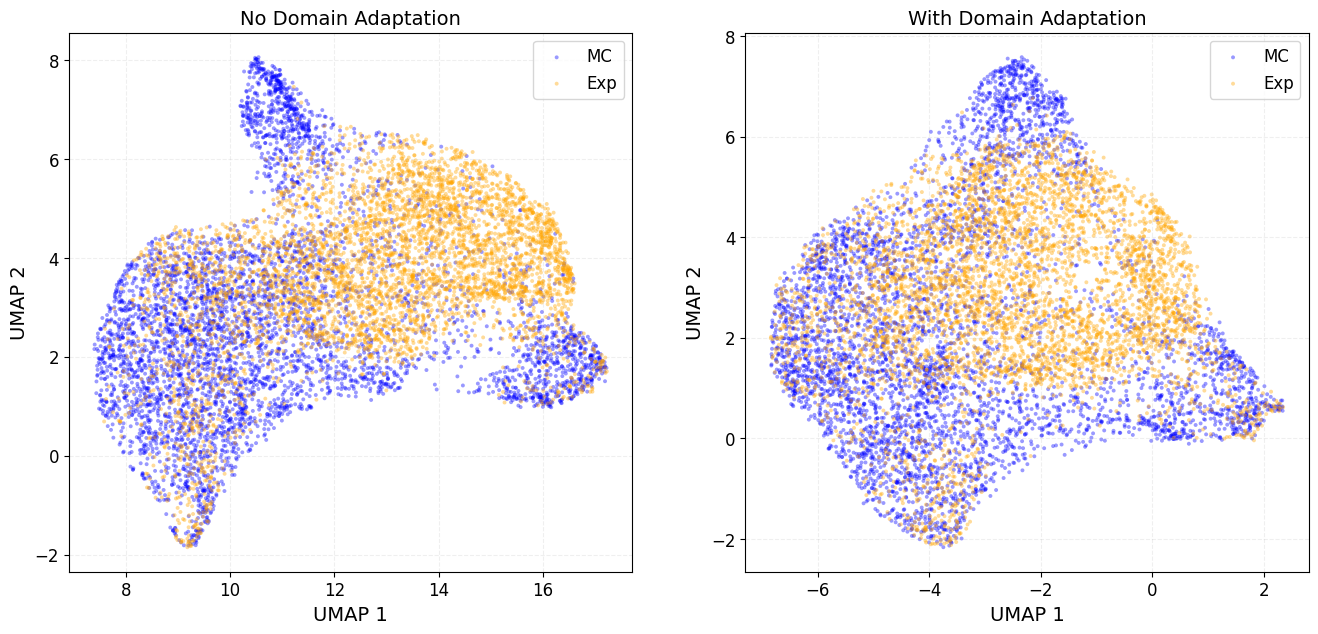

In [28]:
plot_umap_events(
    result_no_da,
    result_da,
    max_events_per_class=5000,
    save_path=output_dir / "umap_events_shared_0-0.png",
    min_strings=0,
    min_hits=0,
)


Hidden shapes after event filters:
MC no-DA : (39936, 512)
Exp no-DA: (39936, 512)
MC DA    : (39936, 512)
Exp DA   : (39936, 512)
Computing shared UMAP on event-level hidden states...


/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


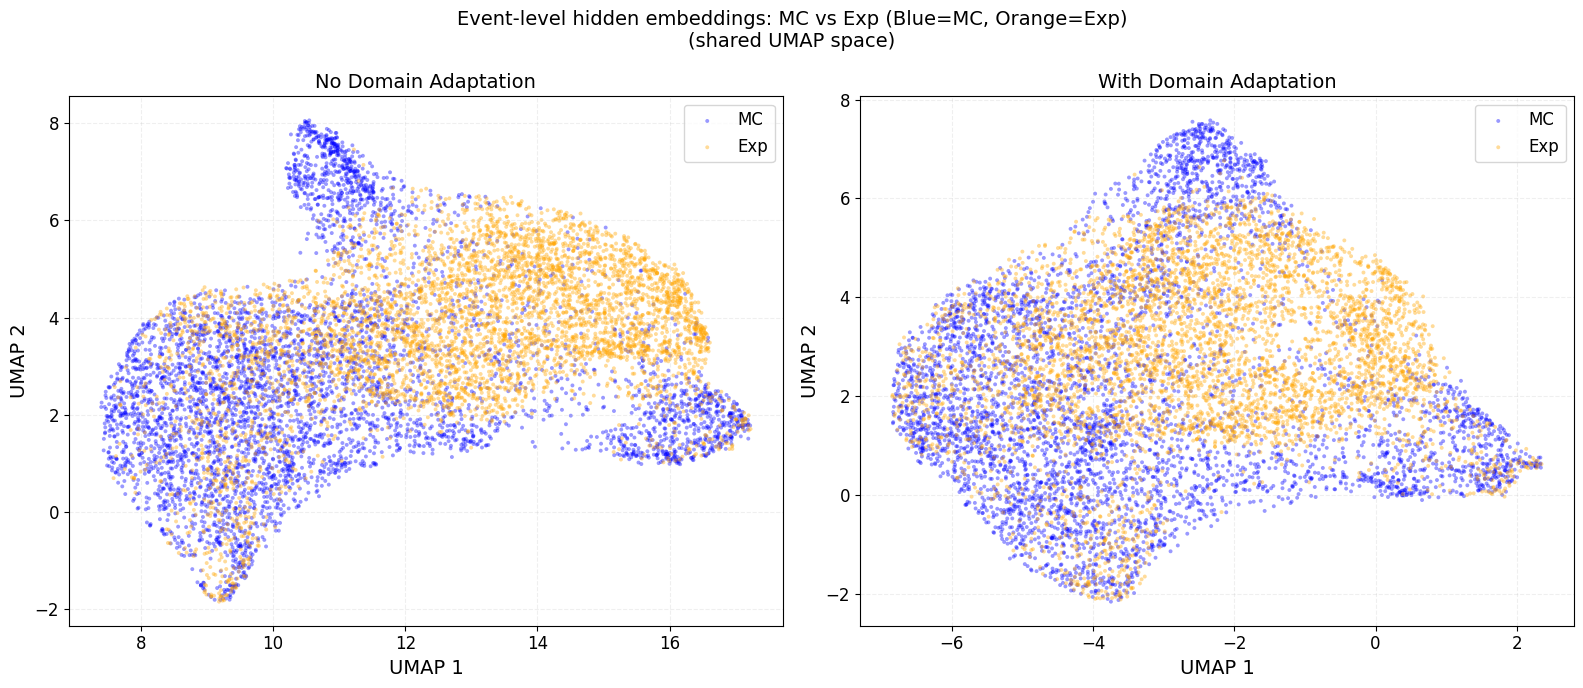

In [ ]:
plot_umap_events(
    result_no_da,
    result_da,
    max_events_per_class=5000,
    save_path=output_dir / "umap_events_shared_8-2.png",
    min_strings=0,
    min_hits=0,
)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import numpy as np


def fast_umap_events(
    data,
    n_components=2,
    n_neighbors=30,
    min_dist=0.3,
    random_state=42,
):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    pca = PCA(n_components=min(50, data_scaled.shape[1]), random_state=random_state)
    data_pca = pca.fit_transform(data_scaled)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric="cosine",
        low_memory=True,
        n_jobs=-1,
        random_state=random_state,
    )
    return reducer.fit_transform(data_pca)


def plot_umap_events(
    result_no_da,
    result_da,
    max_events_per_class=5000,
    save_path=None,
    min_strings=2,
    min_hits=8,
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- MC / Exp, no-DA ---
    res_mc_no  = result_no_da["sig_noise_2020"]
    res_exp_no = result_no_da["exp_data"]

    # --- MC / Exp, DA ---
    res_mc_da  = result_da["sig_noise_2020"]
    res_exp_da = result_da["exp_data"]

    # индексы событий по фильтрам
    idx_mc_no  = get_filtered_event_indices(res_mc_no,  min_strings, min_hits)
    idx_exp_no = get_filtered_event_indices(res_exp_no, min_strings, min_hits)
    idx_mc_da  = get_filtered_event_indices(res_mc_da,  min_strings, min_hits)
    idx_exp_da = get_filtered_event_indices(res_exp_da, min_strings, min_hits)

    # берём скрытые векторы событий
    h_mc_no  = res_mc_no["hidden_states"][idx_mc_no]
    h_exp_no = res_exp_no["hidden_states"][idx_exp_no]
    h_mc_da  = res_mc_da["hidden_states"][idx_mc_da]
    h_exp_da = res_exp_da["hidden_states"][idx_exp_da]

    print("Hidden shapes after event filters:")
    print("MC no-DA :", h_mc_no.shape)
    print("Exp no-DA:", h_exp_no.shape)
    print("MC DA    :", h_mc_da.shape)
    print("Exp DA   :", h_exp_da.shape)

    # выравниваем число событий на класс и не превышаем max_events_per_class
    max_n = min(
        max_events_per_class,
        len(h_mc_no), len(h_exp_no),
        len(h_mc_da), len(h_exp_da)
    )
    rng = np.random.default_rng(42)

    def subsample(h):
        if len(h) > max_n:
            idx = rng.choice(len(h), max_n, replace=False)
            return h[idx]
        return h

    h_mc_no  = subsample(h_mc_no)
    h_exp_no = subsample(h_exp_no)
    h_mc_da  = subsample(h_mc_da)
    h_exp_da = subsample(h_exp_da)

    # стэкаем для двух моделей
    h_no_da = np.vstack([h_mc_no, h_exp_no])
    y_no_da = np.array(["MC"] * len(h_mc_no) + ["Exp"] * len(h_exp_no))

    h_da = np.vstack([h_mc_da, h_exp_da])
    y_da = np.array(["MC"] * len(h_mc_da) + ["Exp"] * len(h_exp_da))

    # --- общий UMAP ---
    all_data = np.vstack([h_no_da, h_da])
    print("Computing shared UMAP on event-level hidden states...")
    all_emb = fast_umap_events(all_data)

    n_no_da = h_no_da.shape[0]
    emb_no_da = all_emb[:n_no_da]
    emb_da    = all_emb[n_no_da:]

    colors = {"MC": "blue", "Exp": "orange"}
    alphas = {"MC": 0.4, "Exp": 0.4}
    sizes = {"MC": 8, "Exp": 8}

    for ax, emb, labels, title in [
        (axes[0], emb_no_da, y_no_da, "No Domain Adaptation"),
        (axes[1], emb_da,    y_da,    "With Domain Adaptation"),
    ]:
        for cls in ["MC", "Exp"]:
            m = labels == cls
            ax.scatter(
                emb[m, 0],
                emb[m, 1],
                c=colors[cls],
                alpha=alphas[cls],
                s=sizes[cls],
                edgecolors="none",
                label=cls,
                rasterized=True,
            )
        ax.set_xlabel("UMAP 1", fontsize=14)
        ax.set_ylabel("UMAP 2", fontsize=14)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=12)
        ax.grid(alpha=0.2, linestyle="--")

    plt.suptitle(
        "Event-level hidden embeddings: MC vs Exp (Blue=MC, Orange=Exp)\n(shared UMAP space)",
        fontsize=14,
        y=0.98,
    )
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

2025-12-01 02:38:15.140805: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-01 02:38:15.140846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-01 02:38:15.141718: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-01 02:38:15.148441: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 02:38:16.274979: W tensorflow/compiler/tf2

Shapes:
MC no-DA : (26624, 512)
Exp no-DA: (29952, 512)
MC DA    : (26624, 512)
Exp DA   : (29952, 512)
Computing shared UMAP on all data...


/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


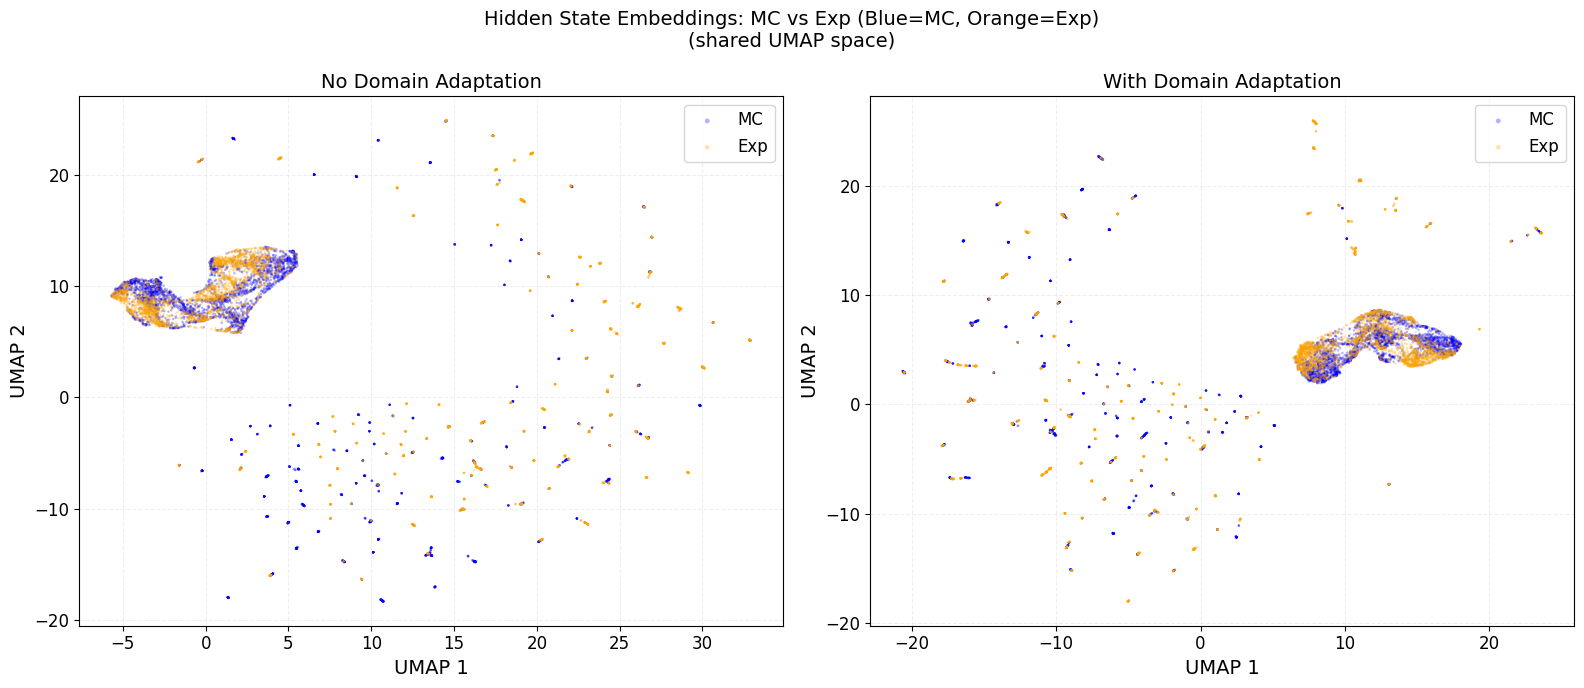

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def fast_umap(data,
              n_components=2,
              n_neighbors=30,
              min_dist=0.3,
              random_state=42):
    """
    UMAP с предварительной стандартизацией и PCA.
    """
    # Стандартизация
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # PCA для ускорения и шумоподавления
    pca = PCA(n_components=min(50, data_scaled.shape[1]), random_state=random_state)
    data_pca = pca.fit_transform(data_scaled)

    # UMAP
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric="cosine",
        low_memory=True,
        n_jobs=-1,
        random_state=random_state,
    )
    return reducer.fit_transform(data_pca)


def plot_umap_comparison(
    result_no_da,
    result_da,
    max_samples=5000,
    save_path=None,
    n_events=200,
):
    """
    UMAP visualization: Compare hidden states (MC vs Exp) with/without DA.
    Один общий UMAP для обеих моделей.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    bs = 128  # batch size в hidden_states

    # --- Step 1: вытаскиваем и сплющиваем hidden states ---
    def flatten_hidden(dataset, key):
        states = dataset[key]["hidden_states"]
        # Берём первые ~n_events событий (по батчам)
        n_batches = min(len(states), max(1, n_events // bs))
        chosen = states[:n_batches]
        flat = [h.reshape(-1, h.shape[-1]) for h in chosen]
        return np.vstack(flat) if flat else np.zeros((0, 512))

    hidden_mc_no_da = flatten_hidden(result_no_da, "sig_noise_2020")
    hidden_exp_no_da = flatten_hidden(result_no_da, "exp_data")
    hidden_mc_da    = flatten_hidden(result_da,    "sig_noise_2020")
    hidden_exp_da   = flatten_hidden(result_da,    "exp_data")

    print("Shapes:")
    print("MC no-DA :", hidden_mc_no_da.shape)
    print("Exp no-DA:", hidden_exp_no_da.shape)
    print("MC DA    :", hidden_mc_da.shape)
    print("Exp DA   :", hidden_exp_da.shape)

    # --- Step 2: равномерно сэмплируем по хитам ---
    min_class = min(
        max_samples,
        len(hidden_mc_no_da),
        len(hidden_exp_no_da),
        len(hidden_mc_da),
        len(hidden_exp_da),
    )
    if min_class == 0:
        raise ValueError("Got empty hidden state arrays, check result_* contents.")

    rng = np.random.default_rng(42)

    idx_mc_no  = rng.choice(len(hidden_mc_no_da),  min_class, replace=False)
    idx_exp_no = rng.choice(len(hidden_exp_no_da), min_class, replace=False)
    idx_mc_da  = rng.choice(len(hidden_mc_da),     min_class, replace=False)
    idx_exp_da = rng.choice(len(hidden_exp_da),    min_class, replace=False)

    combined_no_da = np.vstack([
        hidden_mc_no_da[idx_mc_no],
        hidden_exp_no_da[idx_exp_no],
    ])
    labels_no_da = np.array(["MC"] * min_class + ["Exp"] * min_class)

    combined_da = np.vstack([
        hidden_mc_da[idx_mc_da],
        hidden_exp_da[idx_exp_da],
    ])
    labels_da = np.array(["MC"] * min_class + ["Exp"] * min_class)

    # --- Step 3: общий UMAP для обеих моделей ---
    all_data = np.vstack([combined_no_da, combined_da])
    print("Computing shared UMAP on all data...")
    all_embedding = fast_umap(all_data)

    n_no_da = combined_no_da.shape[0]
    n_da    = combined_da.shape[0]

    embedding_no_da = all_embedding[:n_no_da]
    embedding_da    = all_embedding[n_no_da:n_no_da + n_da]

    # --- Step 4: рисуем ---
    colors = {"MC": "blue", "Exp": "orange"}
    alphas = {"MC": 0.3, "Exp": 0.3}
    sizes = {"MC": 3, "Exp": 3}

    for i, (embedding, labels, title) in enumerate([
        (embedding_no_da, labels_no_da, "No Domain Adaptation"),
        (embedding_da,    labels_da,    "With Domain Adaptation"),
    ]):
        ax = axes[i]
        for cls in ["MC", "Exp"]:
            mask = labels == cls
            ax.scatter(
                embedding[mask, 0],
                embedding[mask, 1],
                c=colors[cls],
                label=cls,
                alpha=alphas[cls],
                s=sizes[cls],
                edgecolors="none",
                rasterized=True,
            )
        ax.set_xlabel("UMAP 1", fontsize=14)
        ax.set_ylabel("UMAP 2", fontsize=14)
        ax.set_title(title, fontsize=14)
        ax.legend(fontsize=12, markerscale=2, loc="best", frameon=True)
        ax.grid(alpha=0.2, linestyle="--")
        ax.set_aspect("auto")

    plt.suptitle(
        "Hidden State Embeddings: MC vs Exp (Blue=MC, Orange=Exp)\n(shared UMAP space)",
        fontsize=14,
        y=0.98,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


# Usage
plot_umap_comparison(
    result_no_da,
    result_da,
    max_samples=5000,
    save_path=output_dir / "umap_comparison_shared_umap.png",
    n_events=300,
)


## KL Divergence on Event-Level Subsamples

Calculate KL divergence on events filtered by number of predicted signal hits (threshold=0.5)


In [154]:
print(result_no_da["sig_noise_2020"]["hidden_states"][0].shape)
print(result_no_da["sig_noise_2020"]["hidden_states"][1].shape)


(128, 100, 512)
(128, 108, 512)


In [34]:
def get_event_level_predictions(
    model, val_loader, is_domain_adaptation=False, has_labels=True, threshold=0.5, num_events=10000):
    """
    Get predictions grouped by events with signal hit counts
    Returns: list of (event_preds, event_labels, num_signal_hits) tuples
    """
    all_events = []
    event_count = 0
    with torch.no_grad():
        for data in tqdm(val_loader, desc="Getting event-level predictions"):
            if event_count >= num_events:
                break
            if len(data) > 3:
                data = data[:3]
            x, y_true, mask = data
            
            x = x.to('cuda')
            y_true = y_true.to('cuda')
            mask = mask.to('cuda')
            
            if is_domain_adaptation:
                output, domain_pred = model(x, mask)
            else:
                output = model(x, mask)
            
            # For per-hit predictions
            if len(output.shape) == 3:  # [batch, seq, classes]
                batch_size = output.shape[0]
                
                for batch_idx in range(batch_size):
                    # Check if we've reached the event limit
                    if event_count >= num_events:
                        break
                    
                    # Get valid hits for this event
                    event_mask = mask[batch_idx] != 0
                    event_output = output[batch_idx][event_mask]
                    
                    # Get probabilities for signal class
                    if len(event_output.shape) == 2:
                        event_probs = torch.sigmoid(event_output[:, 1])
                    else:
                        event_probs = torch.sigmoid(event_output)
                    
                    event_probs_np = event_probs.cpu().numpy()
                    
                    # Count signal hits (above threshold)
                    num_signal_hits = np.sum(event_probs_np >= threshold)
                    
                    if has_labels:
                        event_labels = y_true[batch_idx][event_mask].cpu().numpy()
                    else:
                        event_labels = None
                    
                    all_events.append((event_probs_np, event_labels, num_signal_hits))
                    event_count += 1
            else:
                # Handle non-3D output case if needed
                if event_count >= num_events:
                    break
                # For non-3D output, treat entire batch as one event
                if len(output.shape) == 2:
                    probs = torch.sigmoid(output[:, 1])
                else:
                    probs = torch.sigmoid(output)
                all_events.append((probs.cpu().numpy(), y_true.cpu().numpy() if has_labels else None, len(probs)))
                event_count += 1
            
            # Break outer loop if we've reached the limit
            if event_count >= num_events:
                break
    
    return all_events


def filter_events_by_signal_hits(events, min_signal_hits):
    """Filter events that have at least min_signal_hits signal predictions"""
    filtered_preds = []
    filtered_labels = []
    
    for event_preds, event_labels, num_signal_hits in events:
        if num_signal_hits >= min_signal_hits:
            filtered_preds.extend(event_preds)
            if event_labels is not None:
                filtered_labels.extend(event_labels)
    
    filtered_preds = np.array(filtered_preds)
    filtered_labels = np.array(filtered_labels) if filtered_labels else None
    
    return filtered_preds, filtered_labels


def load_model_event_predictions(checkpoint_path, config_path, model_name, threshold=0.5):
    """Load model and get event-level predictions"""
    print(f"\n{'='*60}")
    print(f"Loading {model_name} from {Path(checkpoint_path).name}")
    print(f"{'='*60}")
    model, config = load_checkpoint_and_config(checkpoint_path, config_path)
    
    train_type = config['train_type']
    is_domain_adaptation = 'domain_adaptation' in train_type
    is_graph = config.get('is_graph', False)
    
    # Preprocess dataset configs
    for i, dc in enumerate(config['dataset_configs']):
        if "DatasetType" not in dc:
            dc["DatasetType"] = BaikalDataset
        elif dc["DatasetType"] == "no_labels":
            dc["DatasetType"] = BaikalDatasetNoLabels
        
        dc["preprocessor"] = create_preprocessor(train_type, dc.get("is_graph", is_graph), dc)
    
    dataloader_dict = create_multi_dataset_dataloader(
        dataset_configs=config['dataset_configs'],
        batch_size=128,
        return_datasets=False,
    )
    
    events_dict = {}
    dataset_names = [dc['name'] for dc in config['dataset_configs']]
    
    # Use train loader for exp_data (unlabeled), val loader for sig_noise_2020 (labeled)
    # Iterate through generators once (don't convert to list - they're infinite)
    val_loaders = []
    for train_loader, val_loader, name in zip(dataloader_dict['train'], dataloader_dict['val'], dataset_names):
        if 'exp' in name.lower():
            val_loaders.append(train_loader)
            print(f"Using TRAIN loader for {name}")
        else:
            val_loaders.append(val_loader)
            print(f"Using VAL loader for {name}")
    
    for i, (loader, name) in enumerate(zip(val_loaders, dataset_names)):
        dataset_type = config['dataset_configs'][i].get('DatasetType', None)
        is_unlabeled = dataset_type == BaikalDatasetNoLabels or dataset_type == 'no_labels'
        
        print(f"Processing {name}...")
        events = get_event_level_predictions(
            model, loader,
            is_domain_adaptation=is_domain_adaptation,
            has_labels=not is_unlabeled,
            threshold=threshold,
            num_events=1000
        )
        events_dict[name] = events
        print(f"  Total events: {len(events)}")
    
    return events_dict


print("Loading event-level predictions for both models...")
events_no_da = load_model_event_predictions(checkpoint_no_da, config_path, "No-DA", threshold=0.5)
events_da = load_model_event_predictions(checkpoint_da, config_path, "DA", threshold=0.5)


Loading event-level predictions for both models...

Loading No-DA from best_sig_noise_2020.ckpt
/home2/ivkhar/Baikal/data/normed/baikal_2020_sig-noise_mid-eq_normed.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home2/ivkhar/Baikal/data/normed/baikal_2020_sig-noise_mid-eq_normed.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home2/ivkhar/Baikal/data/normed/baikal_2020_sig-noise_mid-eq_normed.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/data/baikal_exp_filtered_norm.h5 <KeysViewHDF5 ['norm_param', 'test', 'train', 'val']>
[0.5, 0.5]
Using VAL loader for sig_noise_2020
Using TRAIN loader for exp_data
Processing sig_noise_2020...


Getting event-level predictions:   1%|▏         | 7/489 [00:00<00:35, 13.44it/s]


  Total events: 1000
Processing exp_data...


Getting event-level predictions:   0%|          | 0/4 [00:00<?, ?it/s]


TypeError: ~ (operator.invert) is only implemented on integer and Boolean-type tensors

In [ ]:
# Inspect event structure
# NOTE: Run this cell AFTER loading events (Cell 21)

if 'events_no_da' not in globals() or 'events_da' not in globals():
    print("⚠️  events_no_da and events_da are not defined yet!")
    print("Please run Cell 21 first to load the event-level predictions.")
else:
    print("Event structure inspection:")
    print("="*60)
    
    # Check first dataset
    first_dataset_name = list(events_no_da.keys())[0]
print(f"\nDataset: {first_dataset_name}")
print(f"Total events in No-DA: {len(events_no_da[first_dataset_name])}")
print(f"Total events in DA: {len(events_da[first_dataset_name])}")

# Inspect first event structure
if len(events_no_da[first_dataset_name]) > 0:
    first_event = events_no_da[first_dataset_name][0]
    print(f"\nFirst event structure (No-DA):")
    print(f"  Type: {type(first_event)}")
    print(f"  Length: {len(first_event)}")
    print(f"  Elements:")
    for i, elem in enumerate(first_event):
        if isinstance(elem, np.ndarray):
            print(f"    [{i}]: array shape {elem.shape}, dtype {elem.dtype}")
        else:
            print(f"    [{i}]: {type(elem).__name__} = {elem}")

# Check specific events
if len(events_no_da[first_dataset_name]) > 5:
    event_5 = events_no_da[first_dataset_name][5]
    print(f"\nEvent 5 (No-DA):")
    print(f"  Length: {len(event_5)}")
    if len(event_5) >= 1:
        print(f"  Predictions shape: {event_5[0].shape if isinstance(event_5[0], np.ndarray) else 'N/A'}")
    if len(event_5) >= 3:
        print(f"  Num signal hits: {event_5[2]}")

if len(events_da[first_dataset_name]) > 0:
    event_0 = events_da[first_dataset_name][0]
    print(f"\nEvent 0 (DA):")
    print(f"  Length: {len(event_0)}")
    if len(event_0) >= 1:
        print(f"  Predictions shape: {event_0[0].shape if isinstance(event_0[0], np.ndarray) else 'N/A'}")
    if len(event_0) >= 3:
        print(f"  Num signal hits: {event_0[2]}")


⚠️  events_no_da and events_da are not defined yet!
Please run Cell 21 first to load the event-level predictions.


NameError: name 'first_dataset_name' is not defined

In [ ]:
# Quick check of specific events
# NOTE: Run this cell AFTER loading events (Cell 21)

if 'events_no_da' not in globals() or 'events_da' not in globals():
    print("⚠️  events_no_da and events_da are not defined yet!")
    print("Please run Cell 21 first to load the event-level predictions.")
else:
    first_dataset_name = list(events_no_da.keys())[0]

# Check event 5 from No-DA
if len(events_no_da[first_dataset_name]) > 5:
    event_5_no_da = events_no_da[first_dataset_name][5]
    print(f"Event 5 (No-DA) length: {len(event_5_no_da)}")
    if len(event_5_no_da) >= 1:
        print(f"  Predictions array length: {len(event_5_no_da[0])}")
    print(f"  Event structure: {[type(x).__name__ if not isinstance(x, np.ndarray) else f'array({x.shape})' for x in event_5_no_da]}")

# Check event 0 from DA
if len(events_da[first_dataset_name]) > 0:
    event_0_da = events_da[first_dataset_name][0]
    print(f"\nEvent 0 (DA) length: {len(event_0_da)}")
    if len(event_0_da) >= 1:
        print(f"  Predictions array length: {len(event_0_da[0])}")
    print(f"  Event structure: {[type(x).__name__ if not isinstance(x, np.ndarray) else f'array({x.shape})' for x in event_0_da]}")

    # Your exact query
    print(f"\nYour query results:")
    print(f"  len(events_no_da[{first_dataset_name}][5]): {len(events_no_da[first_dataset_name][5]) if len(events_no_da[first_dataset_name]) > 5 else 'N/A'}")
    print(f"  len(events_da[{first_dataset_name}][0]): {len(events_da[first_dataset_name][0]) if len(events_da[first_dataset_name]) > 0 else 'N/A'}")


⚠️  events_no_da and events_da are not defined yet!
Please run Cell 21 first to load the event-level predictions.


NameError: name 'events_no_da' is not defined

In [ ]:
len(events_no_da[list(events_no_da.keys())[0]][5]), len(events_da[list(events_da.keys())[0]][0])

(3, 3)

In [ ]:
events_no_da

NameError: name 'events_no_da' is not defined

In [ ]:
# Calculate KL divergence for different signal hit thresholds
print("\n" + "="*80)
print("KL DIVERGENCE ANALYSIS: Filtered by Number of Signal Hits per Event")
print("="*80)

mc_name = list(events_no_da.keys())[0] if 'sig_noise' in list(events_no_da.keys())[0] else list(events_no_da.keys())[1]
exp_name = [k for k in events_no_da.keys() if 'exp' in k.lower()][0]

# Different thresholds for minimum signal hits per event
k_hits_thresholds = [4, 8, 10]

results = []

for k_hits in k_hits_thresholds:
    print(f"\n{'='*80}")
    print(f"Filtering: Events with at least {k_hits} signal hits (threshold=0.5)")
    print(f"{'='*80}")
    
    # Filter No-DA model predictions
    mc_preds_no_da_filtered, _ = filter_events_by_signal_hits(events_no_da[mc_name], k_hits)
    exp_preds_no_da_filtered, _ = filter_events_by_signal_hits(events_no_da[exp_name], k_hits)
    
    # Filter DA model predictions
    mc_preds_da_filtered, _ = filter_events_by_signal_hits(events_da[mc_name], k_hits)
    exp_preds_da_filtered, _ = filter_events_by_signal_hits(events_da[exp_name], k_hits)
    
    print(f"\n📊 Sample sizes after filtering:")
    print(f"   No-DA: MC={len(mc_preds_no_da_filtered):,} hits, Exp={len(exp_preds_no_da_filtered):,} hits")
    print(f"   DA:    MC={len(mc_preds_da_filtered):,} hits, Exp={len(exp_preds_da_filtered):,} hits")
    
    # Skip if not enough data
    if len(mc_preds_no_da_filtered) < 100 or len(exp_preds_no_da_filtered) < 100:
        print(f"   ⚠️  Not enough data for reliable KL divergence calculation")
        continue
    
    # Calculate KL divergence for No-DA
    kl_no_da_mc_exp = compute_kl_divergence(mc_preds_no_da_filtered, exp_preds_no_da_filtered)
    kl_no_da_exp_mc = compute_kl_divergence(exp_preds_no_da_filtered, mc_preds_no_da_filtered)
    js_no_da = 0.5 * (kl_no_da_mc_exp + kl_no_da_exp_mc)
    
    # Calculate KL divergence for DA
    kl_da_mc_exp = compute_kl_divergence(mc_preds_da_filtered, exp_preds_da_filtered)
    kl_da_exp_mc = compute_kl_divergence(exp_preds_da_filtered, mc_preds_da_filtered)
    js_da = 0.5 * (kl_da_mc_exp + kl_da_exp_mc)
    
    print(f"\n📊 WITHOUT Domain Adaptation (k_hits >= {k_hits}):")
    print(f"   KL(MC || Exp):  {kl_no_da_mc_exp:.6f}")
    print(f"   KL(Exp || MC):  {kl_no_da_exp_mc:.6f}")
    print(f"   JS Divergence:  {js_no_da:.6f}")
    
    print(f"\n📊 WITH Domain Adaptation (k_hits >= {k_hits}):")
    print(f"   KL(MC || Exp):  {kl_da_mc_exp:.6f}")
    print(f"   KL(Exp || MC):  {kl_da_exp_mc:.6f}")
    print(f"   JS Divergence:  {js_da:.6f}")
    
    improvement = js_no_da - js_da
    pct_improvement = (improvement / js_no_da * 100) if js_no_da > 0 else 0
    
    print(f"\n🎯 Domain Adaptation Effect (k_hits >= {k_hits}):")
    print(f"   JS Divergence:  {js_no_da:.6f} → {js_da:.6f}")
    print(f"   Absolute Change: {improvement:.6f}")
    print(f"   Relative Change: {pct_improvement:.1f}%")
    
    if js_da < js_no_da:
        print(f"   ✅ DA reduces divergence by {abs(pct_improvement):.1f}%")
    else:
        print(f"   ❌ DA increases divergence by {abs(pct_improvement):.1f}%")
    
    results.append({
        'k_hits': k_hits,
        'js_no_da': js_no_da,
        'js_da': js_da,
        'improvement': improvement,
        'pct_improvement': pct_improvement,
        'n_mc_no_da': len(mc_preds_no_da_filtered),
        'n_exp_no_da': len(exp_preds_no_da_filtered),
        'n_mc_da': len(mc_preds_da_filtered),
        'n_exp_da': len(exp_preds_da_filtered)
    })

print("\n" + "="*80)
print("SUMMARY: JS Divergence vs Signal Hit Threshold")
print("="*80)
print(f"{'k_hits':<8} {'JS(No-DA)':<12} {'JS(DA)':<12} {'Improvement':<12} {'Rel. Imp.':<12}")
print("-"*80)
for r in results:
    print(f"{r['k_hits']:<8} {r['js_no_da']:<12.6f} {r['js_da']:<12.6f} {r['improvement']:<12.6f} {r['pct_improvement']:<12.1f}%")
print("="*80)



KL DIVERGENCE ANALYSIS: Filtered by Number of Signal Hits per Event


NameError: name 'events_no_da' is not defined

NameError: name 'results' is not defined

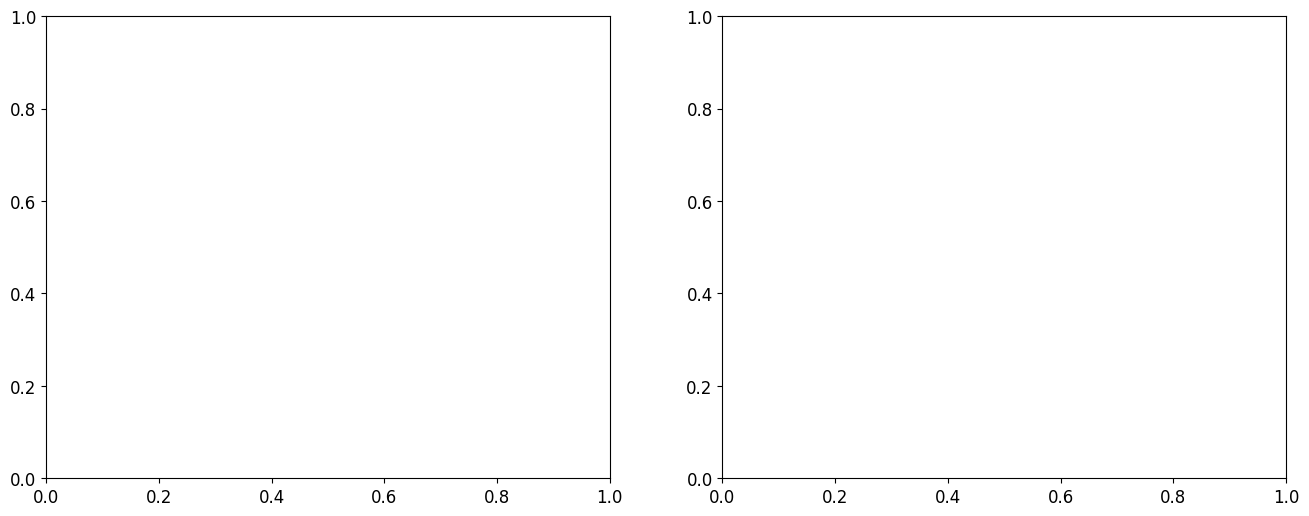

In [94]:
# Visualize JS divergence vs k_hits threshold
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

k_hits_values = [r['k_hits'] for r in results]
js_no_da_values = [r['js_no_da'] for r in results]
js_da_values = [r['js_da'] for r in results]
improvements = [r['pct_improvement'] for r in results]

# Left plot: JS divergence comparison
ax1 = axes[0]
ax1.plot(k_hits_values, js_no_da_values, marker='o', linewidth=2.5, markersize=10, 
         label='No-DA', color='blue')
ax1.plot(k_hits_values, js_da_values, marker='s', linewidth=2.5, markersize=10, 
         label='With DA', color='orange')
ax1.set_xlabel('Minimum Signal Hits per Event (k_hits)', fontsize=14)
ax1.set_ylabel('JS Divergence (MC vs Exp)', fontsize=14)
ax1.set_title('JS Divergence vs Signal Hit Threshold', fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_xticks(k_hits_values)

# Right plot: Relative improvement
ax2 = axes[1]
colors = ['green' if imp > 0 else 'red' for imp in improvements]
ax2.bar(k_hits_values, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Minimum Signal Hits per Event (k_hits)', fontsize=14)
ax2.set_ylabel('Relative Improvement (%)', fontsize=14)
ax2.set_title('Domain Adaptation Effectiveness', fontsize=16, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticks(k_hits_values)

# Add value labels on bars
for i, (k, imp) in enumerate(zip(k_hits_values, improvements)):
    ax2.text(k, imp + (0.5 if imp > 0 else -0.5), f'{imp:.1f}%', 
             ha='center', va='bottom' if imp > 0 else 'top', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / "noise_sig_kl_divergence_vs_k_hits.png", dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_dir / 'noise_sig_kl_divergence_vs_k_hits.png'}")
plt.show()


In [18]:
# Distribution comparison for different k_hits thresholds
fig, axes = plt.subplots(len(k_hits_thresholds), 2, figsize=(16, 6 * len(k_hits_thresholds)))

if len(k_hits_thresholds) == 1:
    axes = axes.reshape(1, -1)

bins = np.linspace(0, 1.0, 60)

for idx, k_hits in enumerate(k_hits_thresholds):
    # Filter predictions
    mc_preds_no_da_filtered, _ = filter_events_by_signal_hits(events_no_da[mc_name], k_hits)
    exp_preds_no_da_filtered, _ = filter_events_by_signal_hits(events_no_da[exp_name], k_hits)
    mc_preds_da_filtered, _ = filter_events_by_signal_hits(events_da[mc_name], k_hits)
    exp_preds_da_filtered, _ = filter_events_by_signal_hits(events_da[exp_name], k_hits)
    
    # Left plot: No-DA
    ax = axes[idx, 0]
    if len(mc_preds_no_da_filtered) > 0 and len(exp_preds_no_da_filtered) > 0:
        ax.hist(mc_preds_no_da_filtered, bins=bins, label=f'{mc_name} (n={len(mc_preds_no_da_filtered):,})',
                density=True, histtype='step', linewidth=2.5, color='blue', alpha=0.8)
        ax.hist(exp_preds_no_da_filtered, bins=bins, label=f'{exp_name} (n={len(exp_preds_no_da_filtered):,})',
                density=True, histtype='step', linewidth=2.5, color='orange', alpha=0.8, linestyle='--')
    
    ax.set_xlabel('Predicted Signal Probability', fontsize=12)
    ax.set_ylabel('Normalized Density (log scale)', fontsize=12)
    ax.set_title(f'No-DA (k_hits >= {k_hits})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, which='both', linestyle=':')
    ax.set_xlim(0, 1.0)
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3)
    
    # Right plot: DA
    ax = axes[idx, 1]
    if len(mc_preds_da_filtered) > 0 and len(exp_preds_da_filtered) > 0:
        ax.hist(mc_preds_da_filtered, bins=bins, label=f'{mc_name} (n={len(mc_preds_da_filtered):,})',
                density=True, histtype='step', linewidth=2.5, color='blue', alpha=0.8)
        ax.hist(exp_preds_da_filtered, bins=bins, label=f'{exp_name} (n={len(exp_preds_da_filtered):,})',
                density=True, histtype='step', linewidth=2.5, color='orange', alpha=0.8, linestyle='--')
    
    ax.set_xlabel('Predicted Signal Probability', fontsize=12)
    ax.set_ylabel('Normalized Density (log scale)', fontsize=12)
    ax.set_title(f'With DA (k_hits >= {k_hits})', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, which='both', linestyle=':')
    ax.set_xlim(0, 1.0)
    ax.set_yscale('log')
    ax.set_ylim(bottom=1e-3)

plt.tight_layout()
plt.savefig(output_dir / "noise_sig_distributions_by_k_hits.png", dpi=150, bbox_inches='tight')
print(f"Saved: {output_dir / 'noise_sig_distributions_by_k_hits.png'}")
plt.show()


NameError: name 'k_hits_thresholds' is not defined

## Multi-Cut Filtering and KL Divergence Analysis

Filter events by multiple criteria and calculate KL divergence on filtered datasets


In [22]:
# Define cut configurations
CUT_CONFIG = {
    'num_un_strings_min': [2, 3],  # Minimum number of unique strings
    'num_signal_hits_min': [8],  # Minimum number of signal hits (based on NN predictions with threshold 0.5)
    'signal_threshold': 0.5,  # Threshold for signal hit classification
    'max_events_per_dataset': 10000,  # Maximum number of events to use from each dataset (None for all)
}

print("Cut Configuration:")
print(f"  num_un_strings_min: {CUT_CONFIG['num_un_strings_min']}")
print(f"  num_signal_hits_min: {CUT_CONFIG['num_signal_hits_min']}")
print(f"  signal_threshold: {CUT_CONFIG['signal_threshold']}")
print(f"  max_events_per_dataset: {CUT_CONFIG['max_events_per_dataset']}")


Cut Configuration:
  num_un_strings_min: [2, 3]
  num_signal_hits_min: [8]
  signal_threshold: 0.5
  max_events_per_dataset: 10000


In [29]:
def get_event_level_predictions_with_strings(model, val_loader, is_domain_adaptation=False, 
                                             has_labels=True, threshold=0.5, num_events=10000):
    """
    Get predictions grouped by events with signal hit counts and num_un_strings
    Returns: list of (event_preds, event_labels, num_signal_hits, num_un_strings) tuples
    """
    all_events = []
    event_count = 0
    
    with torch.no_grad():
        for data in tqdm(val_loader, desc="Getting event-level predictions with strings"):
            if event_count >= num_events:
                break
            # Handle variable-length data tuples
            if len(data) > 3:
                data = data[:3]
            x, y_true, mask = data
            
            x = x.to('cuda')
            y_true = y_true.to('cuda')
            mask = mask.to('cuda')
            
            if is_domain_adaptation:
                output, domain_pred = model(x, mask)
            else:
                output = model(x, mask)
            
            # For per-hit predictions
            if len(output.shape) == 3:  # [batch, seq, classes]
                batch_size = output.shape[0]
                
                for batch_idx in range(batch_size):
                    if event_count >= num_events:
                        break
                    
                    # Get valid hits for this event
                    event_mask = mask[batch_idx] != 0
                    event_output = output[batch_idx][event_mask]
                    
                    # Get probabilities for signal class
                    if len(event_output.shape) == 2:
                        event_probs = torch.sigmoid(event_output[:, 1])
                    else:
                        event_probs = torch.sigmoid(event_output)
                    
                    event_probs_np = event_probs.cpu().numpy()
                    
                    # Count signal hits (above threshold)
                    num_signal_hits = np.sum(event_probs_np >= threshold)
                    
                    # Try to extract num_un_strings from channels if available
                    # Check if we have channel information in the data
                    num_un_strings = None
                    if len(data) >= 4:  # If channels are available
                        try:
                            channels = data[3][batch_idx][event_mask].cpu().numpy()
                            CHANNELS_PER_STRING = 36
                            strings = channels // CHANNELS_PER_STRING
                            num_un_strings = len(np.unique(strings[strings >= 0]))
                        except:
                            pass
                    
                    if has_labels:
                        event_labels = y_true[batch_idx][event_mask].cpu().numpy()
                    else:
                        event_labels = None
                    
                    all_events.append((event_probs_np, event_labels, num_signal_hits, num_un_strings))
                    event_count += 1
    
    return all_events


def filter_events_by_cuts(events, min_num_un_strings=None, min_num_signal_hits=None, signal_threshold=0.5):
    """
    Filter events based on cuts:
    - min_num_un_strings: minimum number of unique strings (if None, skip this cut)
    - min_num_signal_hits: minimum number of signal hits (based on predictions >= signal_threshold)
    
    Returns: filtered predictions array
    """
    filtered_preds = []
    filtered_labels = []
    
    for event_preds, event_labels, num_signal_hits, num_un_strings in events:
        # Apply cuts
        passes = True
        
        if min_num_signal_hits is not None:
            if num_signal_hits < min_num_signal_hits:
                passes = False
        
        if min_num_un_strings is not None and num_un_strings is not None:
            if num_un_strings < min_num_un_strings:
                passes = False
        
        if passes:
            filtered_preds.extend(event_preds)
            if event_labels is not None:
                filtered_labels.extend(event_labels)
    
    filtered_preds = np.array(filtered_preds)
    filtered_labels = np.array(filtered_labels) if filtered_labels else None
    
    return filtered_preds, filtered_labels


def calculate_kl_for_cuts(events_mc, events_exp, cut_config):
    """
    Calculate KL divergence for different cut combinations
    
    NOTE: This function filters CACHED predictions - it does NOT re-run the model.
    The events should already contain all predictions loaded from the model.
    
    Args:
        events_mc: list of cached events from MC dataset (already contains predictions)
        events_exp: list of cached events from Exp dataset (already contains predictions)
        cut_config: dict with cut parameters
    
    Returns:
        list of dicts with results for each cut combination
    """
    results = []
    total_combinations = len(cut_config['num_un_strings_min']) * len(cut_config['num_signal_hits_min'])
    combination_count = 0
    
    for min_strings in cut_config['num_un_strings_min']:
        for min_hits in cut_config['num_signal_hits_min']:
            combination_count += 1
            if combination_count % 5 == 0:
                print(f"  Processing cut combination {combination_count}/{total_combinations}...")
            
            # Filter MC events (from cached predictions - no model run)
            mc_preds_filtered, _ = filter_events_by_cuts(
                events_mc, 
                min_num_un_strings=min_strings,
                min_num_signal_hits=min_hits,
                signal_threshold=cut_config['signal_threshold']
            )
            
            # Filter Exp events (from cached predictions - no model run)
            exp_preds_filtered, _ = filter_events_by_cuts(
                events_exp,
                min_num_un_strings=min_strings,
                min_num_signal_hits=min_hits,
                signal_threshold=cut_config['signal_threshold']
            )
            
            # Skip if not enough data
            if len(mc_preds_filtered) < 100 or len(exp_preds_filtered) < 100:
                continue
            
            # Calculate KL divergence on filtered predictions
            kl_mc_exp = compute_kl_divergence(mc_preds_filtered, exp_preds_filtered)
            kl_exp_mc = compute_kl_divergence(exp_preds_filtered, mc_preds_filtered)
            js_div = 0.5 * (kl_mc_exp + kl_exp_mc)
            
            results.append({
                'min_num_un_strings': min_strings,
                'min_num_signal_hits': min_hits,
                'n_mc': len(mc_preds_filtered),
                'n_exp': len(exp_preds_filtered),
                'kl_mc_exp': kl_mc_exp,
                'kl_exp_mc': kl_exp_mc,
                'js_divergence': js_div
            })
    
    return results


In [30]:
# Load and cache event-level predictions with string information for both models
# NOTE: Model predictions are loaded ONCE and stored. Then we filter the stored predictions
# without re-running the model for each filter combination.

print("="*80)
print("CACHING EVENT-LEVEL PREDICTIONS (Model runs ONCE per dataset)")
print("="*80)

# Note: We'll reuse the existing events that were already loaded earlier
# For now, we'll work with num_signal_hits only, and set num_un_strings to None
# You can extend this later if you have access to channel data

def add_string_info_to_events(events, max_events=None):
    """
    Add None for num_un_strings to existing events, optionally limit number of events.
    This does NOT re-run the model - it just processes already-loaded predictions.
    """
    events_list = [(preds, labels, num_hits, None) for preds, labels, num_hits in events]
    if max_events is not None and len(events_list) > max_events:
        events_list = events_list[:max_events]
        print(f"  Limited to {max_events} events (from {len(events)} total)")
    return events_list

# Cache the events with metadata for filtering
# These are the stored predictions - we'll filter them multiple times without re-running the model
events_no_da_cached = {}
events_da_cached = {}

max_events = CUT_CONFIG.get('max_events_per_dataset', None)

print("\n📦 Caching predictions (already loaded, no model re-run):")
for name in events_no_da.keys():
    print(f"\n  {name}:")
    print(f"    No-DA: {len(events_no_da[name])} events loaded")
    events_no_da_cached[name] = add_string_info_to_events(events_no_da[name], max_events)
    print(f"    DA: {len(events_da[name])} events loaded")
    events_da_cached[name] = add_string_info_to_events(events_da[name], max_events)

print(f"\n✓ Predictions cached and ready for filtering")
print(f"  Using max {max_events if max_events else 'all'} events per dataset")
print(f"  All subsequent filtering will use these cached predictions (no model re-run)")


CACHING EVENT-LEVEL PREDICTIONS (Model runs ONCE per dataset)

📦 Caching predictions (already loaded, no model re-run):


NameError: name 'events_no_da' is not defined

In [25]:
# Calculate KL divergence for different cut combinations
# NOTE: This filters the CACHED predictions - model is NOT re-run
print("\n" + "="*80)
print("KL DIVERGENCE ANALYSIS: Multi-Cut Filtering")
print("(Filtering cached predictions - NO model re-run)")
print("="*80)

mc_name = list(events_no_da_cached.keys())[0] if 'sig_noise' in list(events_no_da_cached.keys())[0] else list(events_no_da_cached.keys())[1]
exp_name = [k for k in events_no_da_cached.keys() if 'exp' in k.lower()][0]

print(f"\n📊 Filtering cached predictions for No-DA model...")
print(f"   MC dataset: {mc_name}")
print(f"   Exp dataset: {exp_name}")
print(f"   Total cut combinations: {len(CUT_CONFIG['num_un_strings_min']) * len(CUT_CONFIG['num_signal_hits_min'])}")

# Calculate for No-DA model (filters cached predictions)
results_no_da = calculate_kl_for_cuts(
    events_no_da_cached[mc_name],
    events_no_da_cached[exp_name],
    CUT_CONFIG
)

print(f"\n📊 Filtering cached predictions for DA model...")
# Calculate for DA model (filters cached predictions)
results_da = calculate_kl_for_cuts(
    events_da_cached[mc_name],
    events_da_cached[exp_name],
    CUT_CONFIG
)

print(f"\n✓ Calculated {len(results_no_da)} cut combinations for No-DA")
print(f"✓ Calculated {len(results_da)} cut combinations for DA")
print(f"✓ All filtering done on cached predictions (model was NOT re-run)")



KL DIVERGENCE ANALYSIS: Multi-Cut Filtering
(Filtering cached predictions - NO model re-run)


IndexError: list index out of range

In [ ]:
# Display results in a table
print("\n" + "="*100)
print("RESULTS: KL Divergence for Different Cut Combinations")
print("="*100)
print(f"{'Min Strings':<12} {'Min Hits':<10} {'N(MC)':<10} {'N(Exp)':<10} {'JS(No-DA)':<12} {'JS(DA)':<12} {'Improvement':<12}")
print("-"*100)

for r_no_da, r_da in zip(results_no_da, results_da):
    improvement = r_no_da['js_divergence'] - r_da['js_divergence']
    pct_improvement = (improvement / r_no_da['js_divergence'] * 100) if r_no_da['js_divergence'] > 0 else 0
    
    print(f"{r_no_da['min_num_un_strings']:<12} {r_no_da['min_num_signal_hits']:<10} "
          f"{r_no_da['n_mc']:<10} {r_no_da['n_exp']:<10} "
          f"{r_no_da['js_divergence']:<12.6f} {r_da['js_divergence']:<12.6f} "
          f"{pct_improvement:>10.1f}%")

print("="*100)


In [ ]:
# Create heatmap visualization of JS divergence vs cuts
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for heatmap
min_strings_list = sorted(set(r['min_num_un_strings'] for r in results_no_da))
min_hits_list = sorted(set(r['min_num_signal_hits'] for r in results_no_da))

# Create matrices
js_no_da_matrix = np.full((len(min_strings_list), len(min_hits_list)), np.nan)
js_da_matrix = np.full((len(min_strings_list), len(min_hits_list)), np.nan)
improvement_matrix = np.full((len(min_strings_list), len(min_hits_list)), np.nan)

for r_no_da, r_da in zip(results_no_da, results_da):
    i = min_strings_list.index(r_no_da['min_num_un_strings'])
    j = min_hits_list.index(r_no_da['min_num_signal_hits'])
    js_no_da_matrix[i, j] = r_no_da['js_divergence']
    js_da_matrix[i, j] = r_da['js_divergence']
    improvement = r_no_da['js_divergence'] - r_da['js_divergence']
    pct_improvement = (improvement / r_no_da['js_divergence'] * 100) if r_no_da['js_divergence'] > 0 else 0
    improvement_matrix[i, j] = pct_improvement

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: No-DA JS Divergence
ax1 = axes[0]
sns.heatmap(js_no_da_matrix, annot=True, fmt='.4f', cmap='YlOrRd', 
            xticklabels=min_hits_list, yticklabels=min_strings_list,
            ax=ax1, cbar_kws={'label': 'JS Divergence'})
ax1.set_xlabel('Min Signal Hits', fontsize=12)
ax1.set_ylabel('Min Unique Strings', fontsize=12)
ax1.set_title('No-DA: JS Divergence', fontsize=14, fontweight='bold')

# Plot 2: DA JS Divergence
ax2 = axes[1]
sns.heatmap(js_da_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=min_hits_list, yticklabels=min_strings_list,
            ax=ax2, cbar_kws={'label': 'JS Divergence'})
ax2.set_xlabel('Min Signal Hits', fontsize=12)
ax2.set_ylabel('Min Unique Strings', fontsize=12)
ax2.set_title('With DA: JS Divergence', fontsize=14, fontweight='bold')

# Plot 3: Improvement (%)
ax3 = axes[2]
sns.heatmap(improvement_matrix, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            xticklabels=min_hits_list, yticklabels=min_strings_list,
            ax=ax3, cbar_kws={'label': 'Improvement (%)'})
ax3.set_xlabel('Min Signal Hits', fontsize=12)
ax3.set_ylabel('Min Unique Strings', fontsize=12)
ax3.set_title('DA Improvement (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(output_dir / "noise_sig_kl_divergence_heatmap.png", dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_dir / 'noise_sig_kl_divergence_heatmap.png'}")
plt.show()


## Summary

All plots have been generated and saved to the `plots/` directory:
- `noise_sig_comparison_distributions.png` - Full distribution comparison (0-1 range)
- `noise_sig_comparison_density_grid.png` - Focused distribution comparison (0-0.3 range)
- `noise_sig_comparison_umap.png` - UMAP visualization of hidden states


In [ ]:
import h5py as h5

# Load paths from config
config_path_xyz = "train_configs/noise_sig_da_k01_gr01.yaml"
with open(config_path_xyz, 'r') as f:
    config_xyz = yaml.safe_load(f)

# Get file paths
mc_path = config_xyz['dataset_configs'][0]['path_to_data']
exp_path = config_xyz['dataset_configs'][1]['path_to_data']

print(f"MC data path: {mc_path}")
print(f"Exp data path: {exp_path}")

# Open H5 files
hfile_mc = h5.File(mc_path, 'r')
hfile_exp = h5.File(exp_path, 'r')

# Load normalization parameters from MC file (reference file)
mean = np.array(hfile_mc['norm_param/mean'])
std = np.array(hfile_mc['norm_param/std'])

print(f"\nNormalization parameters:")
print(f"  Mean shape: {mean.shape}, Mean values: {mean}")
print(f"  Std shape: {std.shape}, Std values: {std}")

# Try different possible paths for data
def get_data_path(hfile, split='test'):
    """Try different possible paths to find data"""
    possible_paths = [
        f'{split}/data/data',
        f'{split}/raw/data/data',
        f'{split}/data',
        f'{split}/raw/data',
    ]
    for path in possible_paths:
        try:
            data = hfile[path]
            print(f"  Found data at: {path}")
            return np.array(data)
        except KeyError:
            continue
    raise KeyError(f"Could not find data in any of the expected paths: {possible_paths}")

# Load data - features order: ['Q', 't', 'x', 'y', 'z']
print(f"\nLoading MC data...")
d_mc = get_data_path(hfile_mc, 'test')
print(f"Loading Exp data...")
d_exp = get_data_path(hfile_exp, 'test')

print(f"\nData shapes:")
print(f"  MC: {d_mc.shape}")
print(f"  Exp: {d_exp.shape}")

# Extract x, y, z (indices 2, 3, 4)
xyz_mc = d_mc[:, [2, 3, 4]]  # x, y, z
xyz_exp = d_exp[:, [2, 3, 4]]

# Denormalize: x_denorm = x_norm * std + mean
xyz_mc_denorm = xyz_mc * std[[2, 3, 4]] + mean[[2, 3, 4]]
xyz_exp_denorm = xyz_exp * std[[2, 3, 4]] + mean[[2, 3, 4]]

# Sample same amount from both datasets
n_samples = min(len(xyz_mc_denorm), len(xyz_exp_denorm))
print(f"\nSampling {n_samples:,} hits from both datasets")

np.random.seed(42)
mc_indices = np.random.choice(len(xyz_mc_denorm), size=n_samples, replace=False)
exp_indices = np.random.choice(len(xyz_exp_denorm), size=n_samples, replace=False)

xyz_mc_sampled = xyz_mc_denorm[mc_indices]
xyz_exp_sampled = xyz_exp_denorm[exp_indices]

print(f"  MC sampled: {xyz_mc_sampled.shape}")
print(f"  Exp sampled: {xyz_exp_sampled.shape}")

# Close files
hfile_mc.close()
hfile_exp.close()


In [ ]:
# Create x, y, z distribution comparison plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

coords = ['x', 'y', 'z']
colors = ['blue', 'green', 'red']

for idx, (coord, color) in enumerate(zip(coords, colors)):
    ax = axes[idx]
    
    # Get data for this coordinate
    mc_data = xyz_mc_sampled[:, idx]
    exp_data = xyz_exp_sampled[:, idx]
    
    # Create histograms
    bins = np.linspace(min(mc_data.min(), exp_data.min()), 
                      max(mc_data.max(), exp_data.max()), 60)
    
    ax.hist(mc_data, bins=bins, label=f'MC (n={len(mc_data):,})', 
            density=True, histtype='step', linewidth=2.5, color='blue', alpha=0.8)
    ax.hist(exp_data, bins=bins, label=f'Exp (n={len(exp_data):,})', 
            density=True, histtype='step', linewidth=2.5, color='orange', 
            linestyle='--', alpha=0.8)
    
    ax.set_xlabel(f'{coord.upper()} coordinate', fontsize=14)
    ax.set_ylabel('Normalized Density', fontsize=14)
    ax.set_title(f'{coord.upper()} Distribution Comparison', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(alpha=0.3, which='both', linestyle=':')
    
    # Add statistics
    mc_mean, mc_std = mc_data.mean(), mc_data.std()
    exp_mean, exp_std = exp_data.mean(), exp_data.std()
    ax.text(0.05, 0.95, f'MC: μ={mc_mean:.2f}, σ={mc_std:.2f}\nExp: μ={exp_mean:.2f}, σ={exp_std:.2f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(output_dir / "xyz_distribution_comparison.png", dpi=150, bbox_inches='tight')
print(f"\nSaved: {output_dir / 'xyz_distribution_comparison.png'}")
plt.show()
